 
<img src="https://th.bing.com/th/id/R.3cd1c8dc996c5616cf6e65e20b6bf586?rik=09aaLyk4hfbBiQ&riu=http%3a%2f%2fcidics.uanl.mx%2fwp-content%2fuploads%2f2016%2f09%2fcimat.png&ehk=%2b0brgMUkA2BND22ixwLZheQrrOoYLO3o5cMRqsBOrlY%3d&risl=&pid=ImgRaw&r=0" 
     style="float: right; margin-right: 30px;" 
     width="120"
     />

---
 
# **PROCESAMIENTO DEL LENGUAJE NATURAL: TAREA 3: Minería de Texto Básica.**
EZAU FARIDH TORRES TORRES.
===
     
<p align="right"> Maestría en Ciencias con Orientación en Matemáticas Aplicadas. </p>
<p align="right"> CENTRO DE INVESTIGACIÓN EN MATEMÁTICAS. </p>
<p align="right"> Fecha de entrega: 21/02/2025. </p>


---

In [1]:
# Necessary libraries.
import numpy as np                                      # library for numerical operations.
import matplotlib.pyplot as plt                         # library for plotting.          
import nltk                                             # library for text processing.
import pandas as pd                                     # library for data manipulation.
from collections import Counter                         # library for counting.
from nltk.tokenize import TweetTokenizer                # library for tokenizing.
from sklearn.manifold import TSNE                       # library for dimensionality reduction.
from sklearn.feature_selection import SelectKBest, chi2 # library for feature selection.
import seaborn as sns                                   # library for plotting.
from sklearn.model_selection import GridSearchCV        # library for hyperparameter tuning.
from sklearn import svm, metrics                        # library for machine learning.
from itertools import combinations                      # library for combinations.
nltk.download('stopwords')                              # download the stopwords.
from nltk.corpus import stopwords                       # library for stopwords.
stopwords_es = set(stopwords.words('spanish'))                    # Get the stopwords in Spanish.
from wordcloud import WordCloud                         # library for wordclouds.
np.random.seed(0)                                       # Set the seed for reproducibility.

# Words to plot.
subsetwords = {"Madre", "asqueroso", "luchona", "#NoEraPenal", "#Holanda", "noche", "buena", "valgo", "perra",
               "ratero", "vieja", "Fox", "asco", "coparmex", "simpatizantes"}

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ezautorres/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


* * *
# **1.- Instrucciones**

Realiza los siguientes puntos en un notebook de Python lo mejor organizado y claro posible. Ponga su nombre completo al archivo de entrega (e.g., adrian_pastor_lopez_monroy.ipynb) y también en la primera celda del notebook junto con el número de Tarea. Al entregar la tarea, sube al classroom el notebook como un archivo (NO archivos zips o similares). El notebook deberá haber sido ejecutado en tú máquina y mostrar el resultado en las celdas. Puede usar libremente el código de la clase "BoW" y "DOR" para completar esta actividad. Puede usar su propio código también, pero no debe usar librerías para hacer BoW y derivados (e.g., sklearn, gensim, etc.).
- El numero de palabras para los puntos 1-5 puede fijarse hasta 5000 con algún corte (e.g., por frecuencia o por mayor tfidf). El número de palabras consideradas para el punto 6 debe ser las 10,000 más frecuentes de toda la colección.
- Sí una palabra del dataset no está en los recursos léxicos, diseñe algo básico para lidiar con ello, o podría simplemente ignorarla en esa representación.
- Para los últimos dos puntos puede ayudarse estudiando la sección 8.5 del libro de Modern Information Retrieval. Ricardo Baeza Yates. Addison Wesley. Se adjuntan copias.

## **1.1.- Se vale pedir ayuda y "copiar".**

Se vale pedir ayuda y/o copiar con atribución entre los miembros de la clase y apegándose estrictamente a los siguientes puntos:
1. Del total de actividades que se solicitan hacer (6 para esta tarea) solo puedes pedir ayuda/copiar en un total de dos.
2. Para los puntos dónde se pide ayuda, brevemente escribe en qué pediste ayuda y a quién.
3. Si tuviste que reusar alguna parte de código que no es tuyo, deja claro dos cosas: 1) brevemente porque tuviste dificultad para hacerlo, 2) cómo lo solucionó tu compañero.

> Asumiendo que en el directorio actual se tienen los archivos de datos y etiquetas
> - mex20_train.txt
> - mex20_train_labels.txt
> 
> para el entrenamiento y
> - mex20_val.txt
> - mex20_val_labels.txt
> 
> para el proceso de validación. Se implementa la función *get_text_from_file()* la cual los carga (de una manera muy similar a la usada en la **práctica 3** y en la **tarea 2**).
>
> El proceso de contrucción del vocabulario se hizo igual que en la **práctica 3** y en la **tarea 2**, usando *TweetTokenizer()* de NLTK. Se obtuvo que el tamaño del vocabulario es 15194.
>
> Para la creación del diccionario, se eligieron las 5000 palabras más frecuentes, como se recomienda en las instrucciones. En el punto 6, se tomaron las $10,000$ palabras más frecuentes.

In [2]:
def get_text_from_file(path_corpus: str, path_labels: str) -> tuple:
    """
    Read the text and labels from the files.

    Parameters
    ----------
    path_corpus : str
        Path to the file containing the text.
    path_labels : str
        Path to the file containing the labels.

    Returns
    -------
    tuple
        A tuple containing the text and the labels.
    """
    with open(path_corpus, 'r', encoding = 'utf-8') as f_corpus, open(path_labels, 'r', encoding = 'utf-8') as f_labels:
        data   = f_corpus.readlines()                 # Read the text line by line.
        labels = list(map(int, f_labels.readlines())) # Read the labels line by line.
    return data, labels

# Load the data.
data_tr, labels_tr   = get_text_from_file('./mex20_train.txt', './mex20_train_labels.txt') # Training data.
data_val, labels_val = get_text_from_file('./mex20_val.txt', './mex20_val_labels.txt')     # Validation data.

print("Number of samples per class in the training data:\n", Counter(labels_tr))
print("Number of samples per class in the validation data:\n", Counter(labels_val))

# Tokenization and word counting.
tokenizer = TweetTokenizer(preserve_case = False, reduce_len = True, strip_handles = True)                                        # Create a tokenizer.
tr_corpus_tk = [tokenizer.tokenize(doc) for doc in data_tr]       # Tokenize the text.
fdist = nltk.FreqDist(word for doc in tr_corpus_tk for word in doc) # Frequency distribution.
print("Vocabulary size  :", len(fdist))
print("Most common words:", fdist.most_common(10))
fdist

# Remove the stopwords from the vocabulary.
quit_stop_words = [ 
            (word, freq)
            for word, freq in fdist.most_common()
            if word not in stopwords_es
        ]
quit_stop_words # Fdist sin stopwords

max_vocab_size = 5000
dict_indices = {
            word: idx
            for idx, (word, _) in enumerate(quit_stop_words[: 5000])
        }
top_words = set(dict_indices.keys())
print("Top words:\n", top_words)
dict_indices

Number of samples per class in the training data:
 Counter({0: 3759, 1: 1519})
Number of samples per class in the validation data:
 Counter({0: 418, 1: 169})
Vocabulary size  : 13071
Most common words: [('que', 3111), ('de', 3094), (',', 3016), ('.', 2604), ('la', 2269), ('a', 2205), ('y', 2098), ('no', 1819), ('me', 1475), ('!', 1435)]
Top words:
 {'16años', 'altar', 'corrientes', 'bloqueo', 'pantalón', 'horror', 'culera', 'dijo', 'encontrarme', 'jugar', '😖', 'harta', 'película', 'llevaba', 'traidor', 'inepto', 'calles', 'mostrarse', 'vuelva', 'pónganse', 'caes', '#niunamenos', 'chuky', 'alma', 'toco', 'seguidores', 'santander', '🔥', 'inventa', 'comentarios', 'falta', 'enamoro', 'prestamela', 'disfrutando', 'politicos', 'querido', 'hospital', 'maduras', 'anoche', '✌', 'desear', 'café', 'salio', 'dirán', 'rey', 'mañana', 'amika', 'defecto', 'cuentas', 'malditas', 'boca', 'estooo', 'agusto', 'maíz', 'mosco', 'pocos', 'acabando', 'toma', 'superenlo', 'deciden', 'sobra', 'fregada', 'parci

{',': 0,
 '.': 1,
 '!': 2,
 'verga': 3,
 'madre': 4,
 '?': 5,
 'putos': 6,
 'si': 7,
 '"': 8,
 'putas': 9,
 '...': 10,
 '😂': 11,
 'loca': 12,
 'gorda': 13,
 'bien': 14,
 '¿': 15,
 'feas': 16,
 'pinche': 17,
 'puta': 18,
 ':': 19,
 'ser': 20,
 'puto': 21,
 'hdp': 22,
 'tan': 23,
 'así': 24,
 '…': 25,
 'mamar': 26,
 'q': 27,
 'quiero': 28,
 'solo': 29,
 '¡': 30,
 '<url>': 31,
 'joto': 32,
 'cosas': 33,
 'marica': 34,
 'siempre': 35,
 'ahora': 36,
 'hace': 37,
 'ver': 38,
 'vale': 39,
 'mejor': 40,
 'hoy': 41,
 'gente': 42,
 'vida': 43,
 '️': 44,
 'va': 45,
 'voy': 46,
 'pinches': 47,
 'día': 48,
 'jajaja': 49,
 'vez': 50,
 'mierda': 51,
 'luchona': 52,
 '😭': 53,
 '-': 54,
 '(': 55,
 'pues': 56,
 ')': 57,
 'hijo': 58,
 '😍': 59,
 'jajajaja': 60,
 'alguien': 61,
 'tontas': 62,
 'hacer': 63,
 '😡': 64,
 '“': 65,
 'toda': 66,
 'cagado': 67,
 'mas': 68,
 'gusta': 69,
 '”': 70,
 'pendejo': 71,
 'tonta': 72,
 'mamando': 73,
 'puedo': 74,
 'hijos': 75,
 '🙄': 76,
 'mal': 77,
 'nunca': 78,
 '..': 79

Del diccionario creado anteriormente, intercambiamos la indexación, es decir, ahora los índices del diccionario serán el número y devolverá la palabra correspondiente a ese índice.

In [6]:
dict_index_inv = {}
for w in dict_indices:
    dict_index_inv[dict_indices[w]] = w

print("Some index:", dict_index_inv[2942])

Some index: coparmex


## **1.2.- Selección de Términos y DTRs.**

Importante: Para cada punto debe elaborar una pequeña discusión de al menos un pequeño parráfo.

> Para no repetir mucho código al momento de graficar, se implementa la función *plots()* la cual dibuja el gráfico de constelación de las palabras en la matriz dada y las flechas desde el origen hasta las palabras en el subconjunto de forma muy similar a como se revisó en la **práctica 4**.
>
> En ocasiones marca algunos warnings debido a que no reconoce los emojis de los tweets.

In [7]:
def plots(matrix: np.ndarray, words: list, constellation: bool = True, subsetwords: set = subsetwords) -> None:
    """
    Plot the constellation plot of the words in the matrix and the arrows from the origin to the words in the subset.

    Parameters
    ----------
    matrix : np.ndarray
        Matrix to plot.
    words : list
        List of words.
    constellation : bool, optional
        Plot the constellation of the words, by default True. If False, only the arrows for the subset
        of words are plotted.
    subsetwords : set, optional
        Subset of words to plot, by default subsetwords given above.
    """
    max_x, max_y = np.amax(matrix, axis = 0)                             # Get the maximum values of the matrix.

    if constellation:                                                    # Plot the constellation of the words.
        plt.figure(figsize = (15,15), dpi = 300)                         # Create a figure.
        plt.xlim(-max_x, max_x)                                          # Set the limits of the x-axis.
        plt.ylim(-max_y, max_y)                                          # Set the limits of the y-axis.
        plt.scatter(matrix[:,0], matrix[:,1], s = 10, color = 'black')   # Scatter plot.
        for idx, word in enumerate(words):                               # Annotate the words.
            x, y = matrix[idx]                                           # Get the coordinates of the word.
            if word in stopwords_es:                                             
                plt.annotate(word, (x,y), color = 'red', fontsize = 8)   # Annotate the stopwords.
            else:
                plt.annotate(word, (x,y), color = 'black', fontsize = 8) # Annotate the words.
    
    else:                                                                # Plot the arrows from the origin to the subset of words.
        filtered_data = [(word, matrix[idx]) for word, idx in zip(words, range(len(words))) if word in subsetwords]
        
        plotted_subsetwords, subreduced_matrix = zip(*filtered_data) if filtered_data else ([], []) # Unzip the data.
        subreduced_matrix = np.array(subreduced_matrix) if subreduced_matrix else np.empty((0,2))   # Convert the data to numpy arrays.
    
        fig, ax = plt.subplots(figsize = (10,10), dpi = 300)                                  # Create the figure.
        for x, y in subreduced_matrix:                                                        # Arrows since the origin.
            ax.arrow(0, 0, x, y, head_width = 0.5, head_length = 0.5, fc = 'red', ec = 'red') # Plot the arrows.
        ax.scatter(subreduced_matrix[:,0], subreduced_matrix[:,1], s = 10, color = 'black')   # Scatter plot.
        for word, (x,y) in zip(plotted_subsetwords, subreduced_matrix):                       # Annotate the words.
            ax.annotate(word, (x,y), color = 'black', fontsize = 10, ha = 'right')         
        plt.show()

### **1.2.1.- Programa y visualiza TCOR. Puede hacer esto de forma similar a como el profesor lo hizo en la Práctica 4 con DOR. El pesado puede ser el que el profesor sugirió en clase TCOR o PPMI como lo sugiere Dan Jurafsky; hacer al menos dos gráficas, la de constelación de palabras y subconjunto para ver algunas palabras con flechas.**

> El ejercicio se hará de manera similar a la **práctica DOR**, en donde se utiliza la bolsa de palabras con pesado binario y se somete la salida a la función **compute_DOR()**. Ahora, para el caso de TCOR, necesitamos que las entradas de la matriz TCOR sean:
>
>$$
>tfitf(t_k,t_j) = tf(t_k,t_j) \cdot \log{\frac{|\tau|}{\#\tau(t_k)}}
>$$
> donde $\#\tau(t_k)$ denota el número de términos en el diccionario $\tau$ que co-ocurren con $t_k$ en al menos un documento y
>$$
> tf(t_k,t_j) = 1 + \log{\#(t_k,t_j)} \text{ si } \#(t_k,t_j) \text{ o $0$ en otro caso}.
>$$
> donde $\#(t_k,t_j)$ es el número de documentos en los cuales $t_k$ y $t_j$ co-ocurren.
>
> Notemos que para un cálculo rápido de las expresiones anteriores, se debe trabajar con una **bolsa de palabras con pesado binario** ya que esta nos ayuda a extraer fácilmente expresiones como $\#(t_k,t_j)$ y $\#\tau(t_k)$.
>
>Así, contruimos la BoW binaria con la siguiente función usada en la tarea anterior:

In [8]:
def build_bow_binary_weights(docs: list, vocab: list, word_index: dict, normalized: bool = False) -> np.ndarray:
    """
    Build a bag of words matrix. Rows are documents and columns are words. 1 means that the word is present in the
    document and 0 means that the word is not present in the document.

    Parameters
    ----------
    docs : list
        List of documents.
    vocab : list
        List of words.
    word_index : dict
        Dictionary with the indices of the words.
    normalized : bool, optional
        Normalize the rows of the matrix by their L2 norm, by default False.

    Returns
    -------
    np.ndarray
        Bag of words matrix.
    """
    bow = np.zeros((len(docs), len(vocab)), dtype = float) # Create a matrix of zeros.
    for i, doc in enumerate(docs):                         # Iterate over the documents.
        word_counts = Counter(tokenizer.tokenize(doc))     # Tokenize the document.
        for word in word_counts:                           # Iterate over the words.
            if word in word_index:                         # If the word is in the vocabulary.
                bow[i, word_index[word]] = 1               # Set the corresponding entry to 1.

    if normalized: # Normalize the rows of the matrix by their L2 norm.
        
        norms = np.linalg.norm(bow, axis = 1, keepdims = True) # Calculate the L2 norm of each row.
        norms[norms == 0] = 1                                  # Avoid division by zero.
        bow /= norms                                           # Normalize the rows.

    return bow

# Build the bag of words matrices.
BOW_tr  = build_bow_binary_weights(data_tr, top_words, dict_indices)  # Binary bag of words matrix for the training data.
print("Shape of the training data:", BOW_tr.shape)

Shape of the training data: (5278, 5000)


> Investigando en la bibliografía, encontré que dada una bolsa de palabras binaria representada en una matriz $X$ (SIN NORMALIZAR) donde:
>- Las filas representan los documentos.
>- Las columnas representan las palabras.
>- $X_{i,k} = 1$  si la palabra $t_k$ está presente en el documento $i$, y $0$ en caso contrario,
>
> entonces, el número de documentos en los que ambas palabras $t_k$ y $t_j$ co-ocurren, denotado en nuestro problema como $\#(t_k, t_j)$, se calcula de la siguiente manera:
>$$
> \#(t_k, t_j) = \sum_{i} X_{i,k}X_{i,j}
>$$
> es decir, se multiplica la columna $k$ con la columna $j$ elemento a elemento y luego se suman. Es decir, la matriz de co-ocurrencia $C$ en donde la entrada $C_{k,j}$ representa el número de documentos en los que $t_k$ y $t_j$ aparecen, está dada por:
>$$
> C = X^{T} \cdot X.
>$$
>Con esto, para calcular $\#\tau(t_k) =$ el número de términos en el diccionario $\tau$ que co-ocurren con $t_k$ en al menos un documento, basta con contar cuantas entradas de las filas de $C$ son mayores que cero.
>
> Usando todo esto, implementamos la función *compute_TCOR()* y creamos la matriz *TCOR_BASE* con tamaño $5000\times5000$:
>
> **NOTA** Al operar con la matriz de co-ocurrencia es importante eliminar la autocoócurrencia, es decir, hacer la diagonal de la matriz igual a cero, así evitamos que cada palabra sea su par más similar.

In [9]:
def compute_TCOR(BoW: np.ndarray, subset: list = None, normalize: bool = True) -> np.ndarray:
    """
    Compute the Term Co-Occurrence Representation (TCOR) matrix. The TCOR matrix is computed as follows:
        TCOR(t_k, t_j) = tf(t_k, t_j) * log(|tau| / #tau(t_k)), where:
            - tf(t_k, t_j) = 1 + log(#(t_k, t_j)) if #(t_k, t_j) > 0, 0 otherwise.
            - |tau| is the number of terms.
            - #tau(t_k) is the number of co-occurring terms for term t_k.

    Parameters
    ----------
    BoW : np.ndarray
        Bag of words matrix. Rows are documents and columns are words.
    subset : list, optional
        Subset of documents to consider, by default None.
    normalize : bool, optional
        Normalize the matrix, by default True.

    Returns
    -------
    np.ndarray
        TCOR matrix. Rows and columns are words.
    """
    BoW = BoW if subset is None else BoW[subset] # Get the subset of the documents.
    n_terms = BoW.shape[1]                       # Get the number of terms. The result is a matrix of shape (terms, terms).

    C = BoW.T @ BoW                             # Compute the co-occurrence matrix.
    np.fill_diagonal(C, 0)                      # Remove self-co-occurrence.
    tf = np.where(C > 0, 1 + np.log(C+1e-8), 0) # Compute the TF term 1 + log(C) if C > 0, 0
    tau_k = np.count_nonzero(C, axis = 1)       # Compute number of co-occurring terms for each term t_k
    itf = np.log(n_terms / tau_k).reshape(-1,1) # Compute term log(|tau| / #tau(t_k))
    TCOR = tf * itf.T                           # Compute TCOR matrix.
    
    if normalize: # Normalize the rows of the matrix by their L2 norm.

        norms = np.linalg.norm(TCOR, axis = 1, keepdims = True) # Calculate the L2 norm of each row.
        norms[norms == 0] = 1                                   # Avoid division by zero.
        TCOR /= norms                                           # Normalize the rows.

    return TCOR

# Compute the TCOR matrix.
TCOR_BASE = compute_TCOR(BOW_tr)
print("Shape of the TCOR matrix:\n", TCOR_BASE.shape)

Shape of the TCOR matrix:
 (5000, 5000)


Al igual que en la **práctica 4**, usamos Skelarn para la selección de características. Seleccionamos los $700$ índices más relevantes para la clase de interés y seleccionamos los 700 términos correspondientes (esto para no saturar la constelación y poder hacer conclusiones).

In [10]:
# Select the 300 best features.
features = SelectKBest(chi2, k = 700).fit(BOW_tr, labels_tr)

# Get the indices of the best features.
best = features.get_support(indices = True)
print("Los primeros indices son:\n", best[:15])

# Get the words corresponding to the best features.
t_words = [dict_index_inv[i] for i in best]
print("Correspondientes a las palabras:\n", t_words[:10])

Los primeros indices son:
 [ 2  3  4  6  8 12 13 15 16 17 18 19 21 22 27]
Correspondientes a las palabras:
 ['!', 'verga', 'madre', 'putos', '"', 'loca', 'gorda', '¿', 'feas', 'pinche']


Seleccionamos la fila correspondiente a cada palabra en DOR_BASE y se aplica TSNE para encontrar las características más relevantes que se proyectan a $R^2$.

In [11]:
# Get the rows corresponding to the best features.
t_matrix = np.array([TCOR_BASE[dict_indices[w]] for w in t_words])
print("Dimension matriz antes de TSNE:\n", t_matrix.shape)

# Reduce the dimensionality of the matrix.
reduced_matrix = TSNE(n_components = 2).fit_transform(t_matrix)
print("Dimension matriz reducida:\n", reduced_matrix.shape)

Dimension matriz antes de TSNE:
 (700, 5000)
Dimension matriz reducida:
 (700, 2)


**Constelación de palabras**

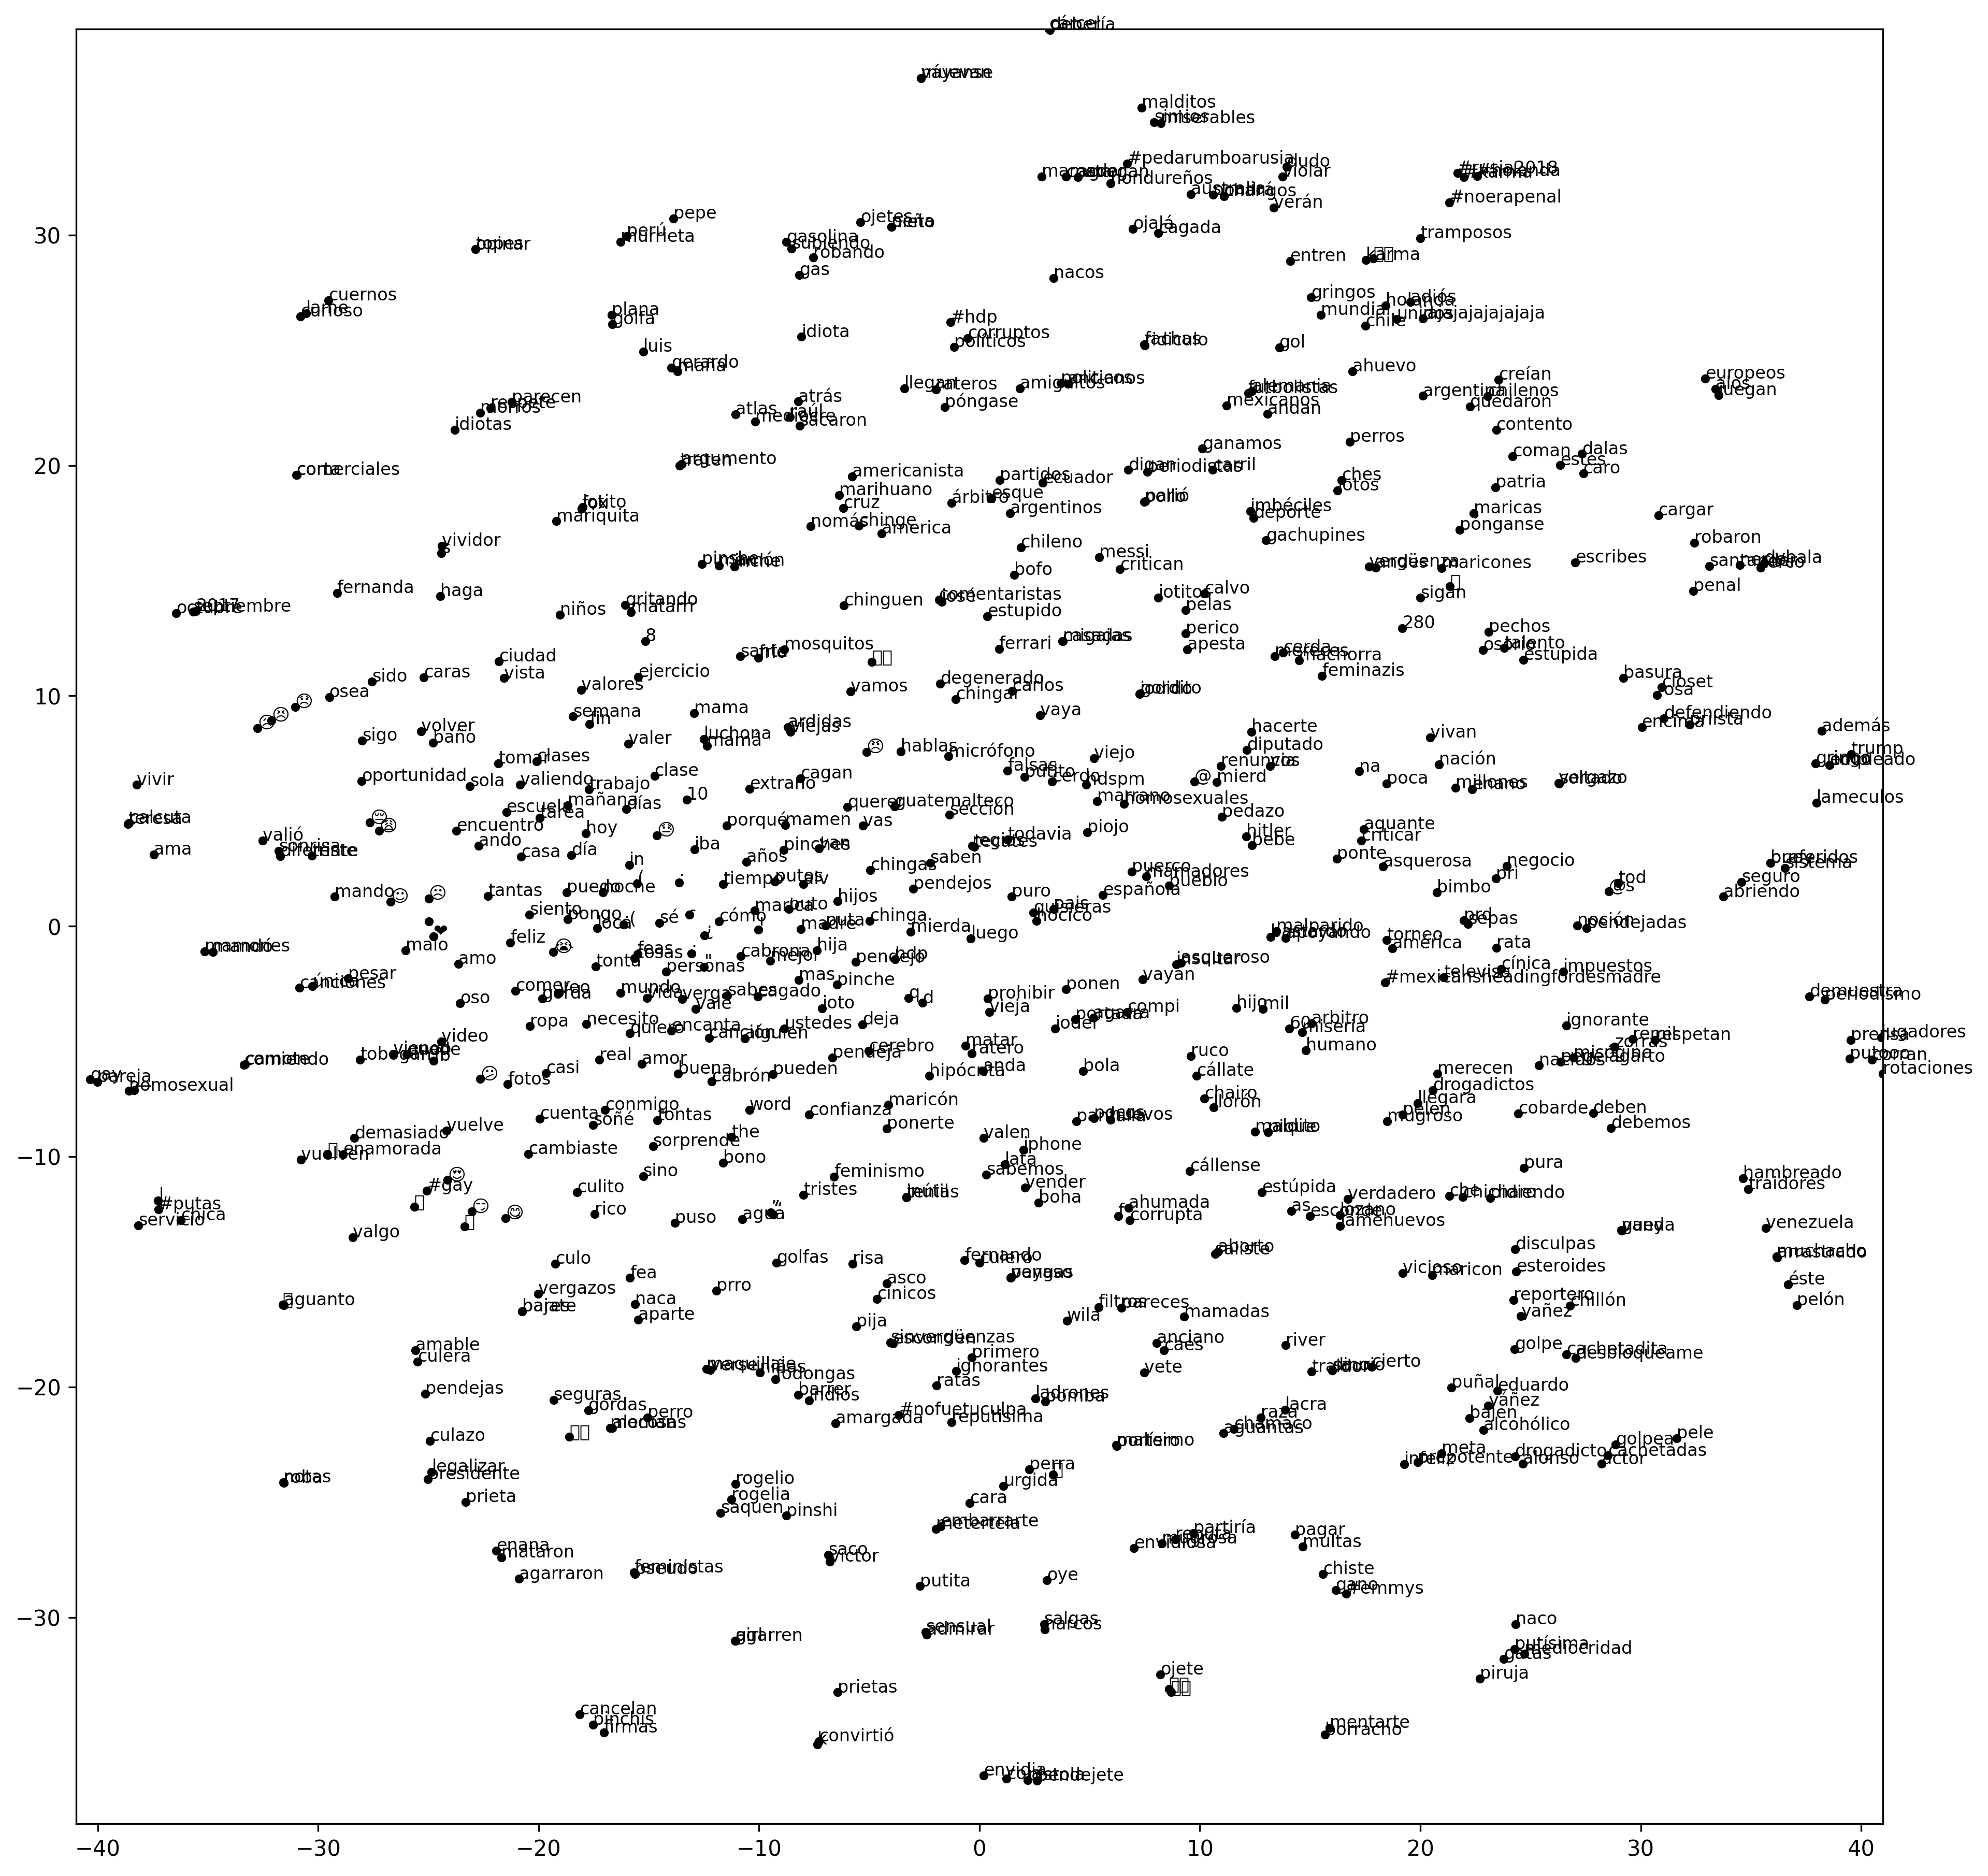

In [13]:
plots(reduced_matrix, t_words, constellation = True)

**Subconjunto de constelación de palabras**

Y esto nos ayuda a hacer conclusiones visuales con palabras de interés (y que también han sido tomadas como importantes por tsne)

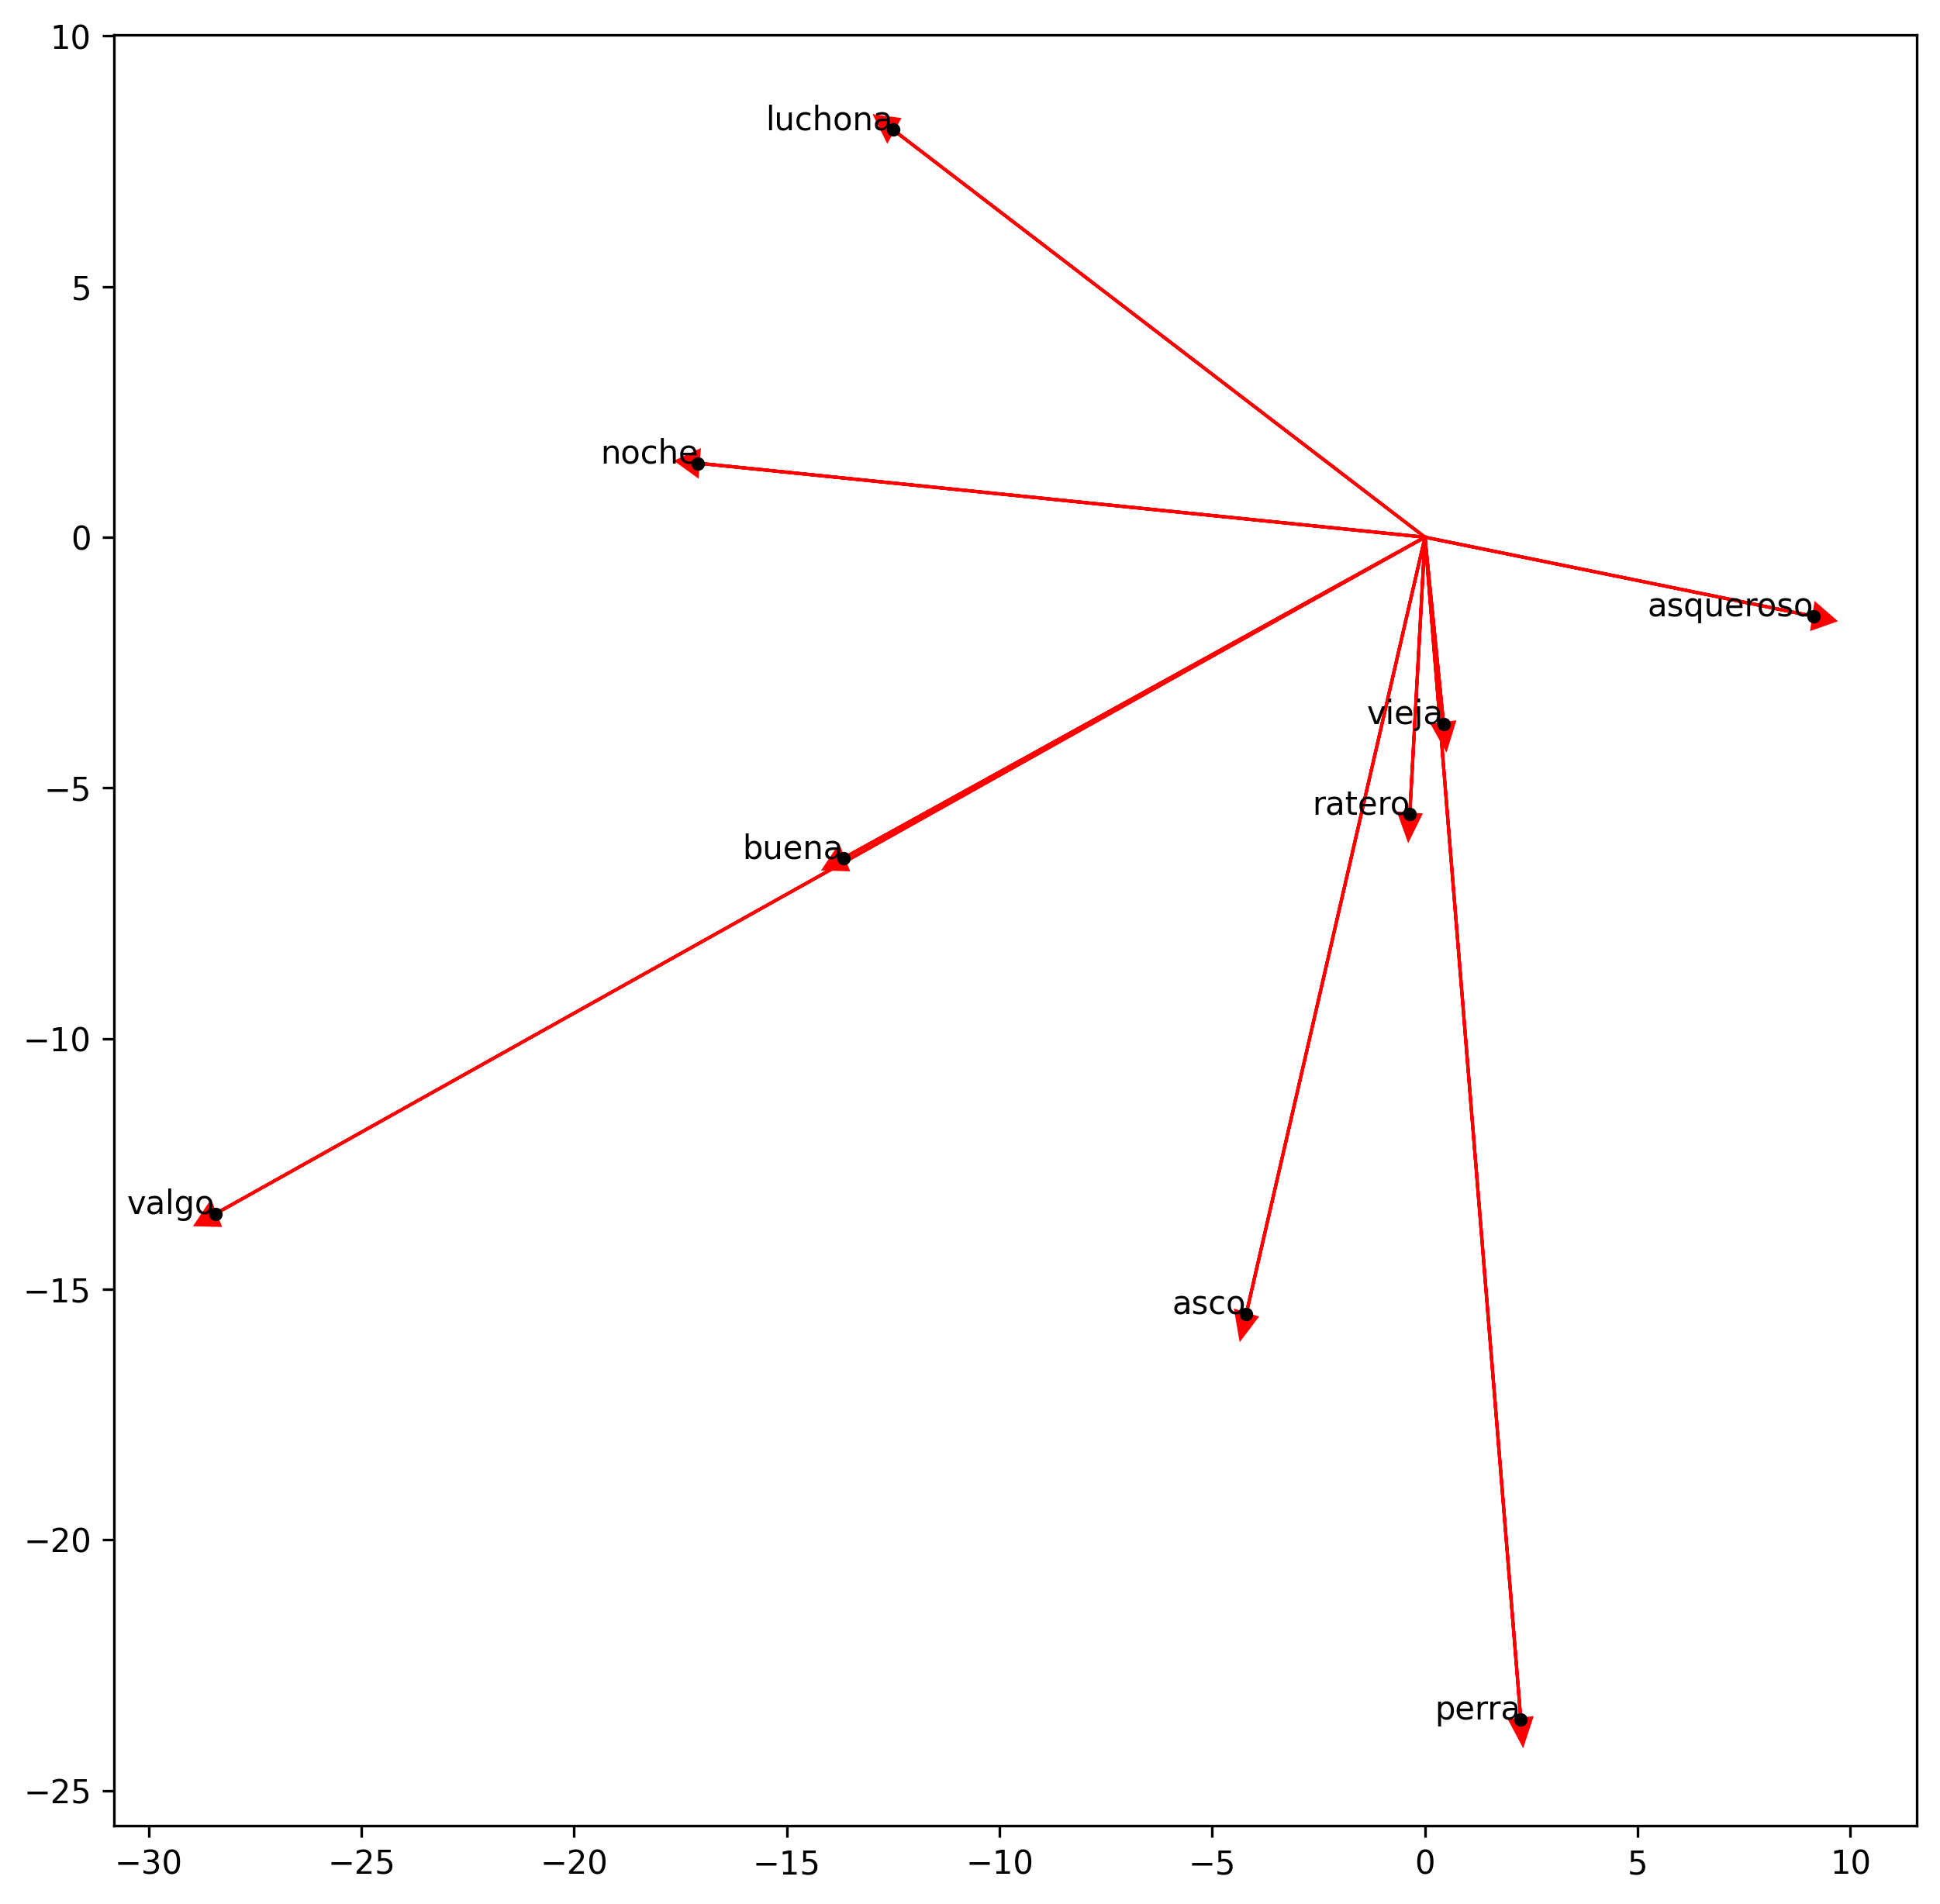

In [14]:
plots(reduced_matrix, t_words, constellation = False)

>**COMENTARIO:** 
>
>Podemos notar que este ejemplo es diferente al de la implementación de DOR, ya que DOR, genera una matriz de dimensión $(n_{docs})\times(n_{docs})$ que en general, $n_docs$ es mucho menor que $n_terms$. Para el caso de TCOR, contamos con una matriz a operar de $(n_{terms})\times(n_{terms})=(5000)\times(5000)$ que es bastante grande y el tiempo de ejecución para los cálculos correspondientes fue bastante más alto a comparación al caso de DOR.
>
>Se hizo una reducción a $(300\times 2)$ para hacer la constelación de palabras y no sobrecargar la imagen.

### **1.2.2.- Programa y visualiza alguna implementación de Random Indexing. Puedes hacer esto reusando parte del código del profesor en la Práctica 4 con DOR. Hacer al menos dos gráficas, la de constelación de palabras y subconjunto para ver algunas palabras con flechas.**

> Se comienza definiendo la función *random_indexing()* en la cual se comienza creando una matriz de los index vectors que tienen valores dispersos $\pm 1$, y el resto en 0. Cada fila de esta matriz es un index vector de dimensión $k = 300 << 5000$ (en algún paper vi que esta elección era usual). Se tokenizan todos los documentos y se obtiene la lista de índices de palabras del diccionario. Finalmente, cada palabra suma los vectores de todas las demás palabras en el documento.

In [15]:
# Function to create a Random Indexing representation
def random_indexing(docs: list, vocab: list, word_index: dict, k: int = 300, normalized: bool = True) -> np.ndarray:
    """
    Create a Random Indexing representation of the documents. The Random Indexing matrix is computed as follows:
        - Randomly generate k-dimensional vectors for each term in the vocabulary.
        - For each document, aggregate the context vectors of the terms in the document.

    Parameters
    ----------
    docs : list
        List of documents.
    vocab : list
        List of words.
    word_index : dict 
        Dictionary with the indices of the words.
    k : int, optional
        Dimensionality of the Random Indexing matrix, by default 300.
    normalized : bool, optional
        Normalize the matrix, by default True.

    Returns
    -------
    np.ndarray
        Random Indexing matrix.
    """
    n_terms = len(vocab)                                                 # Number of terms.
    index_vectors = np.random.choice(10*[0]+[-1,1], size = (n_terms, k)) # Index vectors.
    ri_matrix = np.zeros((n_terms, k))                                   # Initialize the RI matrix.

    for doc in docs:                                                              # Iterate over the documents.
        words = tokenizer.tokenize(doc)                                           # Tokenize the document.                  
        word_indices = [word_index[word] for word in words if word in word_index] # Get the indices of the words in the document.
        
        for idx in word_indices:                                 # Iterate over the words in the document.
            for context_idx in word_indices:                     # Iterate over the context words.
                if idx != context_idx:                           # If the words are different (not the same word).
                    ri_matrix[idx] += index_vectors[context_idx] # Add the context vector to the word vector.
    
    if normalized: # Normalize the rows of the matrix by their L2 norm.
        
        norms = np.linalg.norm(ri_matrix, axis = 1, keepdims = True) # Calculate the L2 norm of each row.
        norms[norms == 0] = 1                                        # Avoid division by zero.
        ri_matrix /= norms                                           # Normalize the rows.

    return ri_matrix

# Generate the Random Indexing matrix
RI_matrix = random_indexing(data_tr, top_words, dict_indices, k = 300)
RI_matrix_val = random_indexing(data_val, top_words, dict_indices, k = 300)
print("Shape of the RI matrix:", RI_matrix.shape)

Shape of the RI matrix: (5000, 300)


Se aplica TSNE al igual que antes para encontrar las características más relevantes que se proyectan a $R^2$:

In [16]:
# Reduce the dimensionality of the matrix with t-SNE.
reduced_RI = TSNE(n_components = 2).fit_transform(RI_matrix)
print("Reduced RI matrix shape:", reduced_RI.shape)

Reduced RI matrix shape: (5000, 2)


**Constelación de palabras**

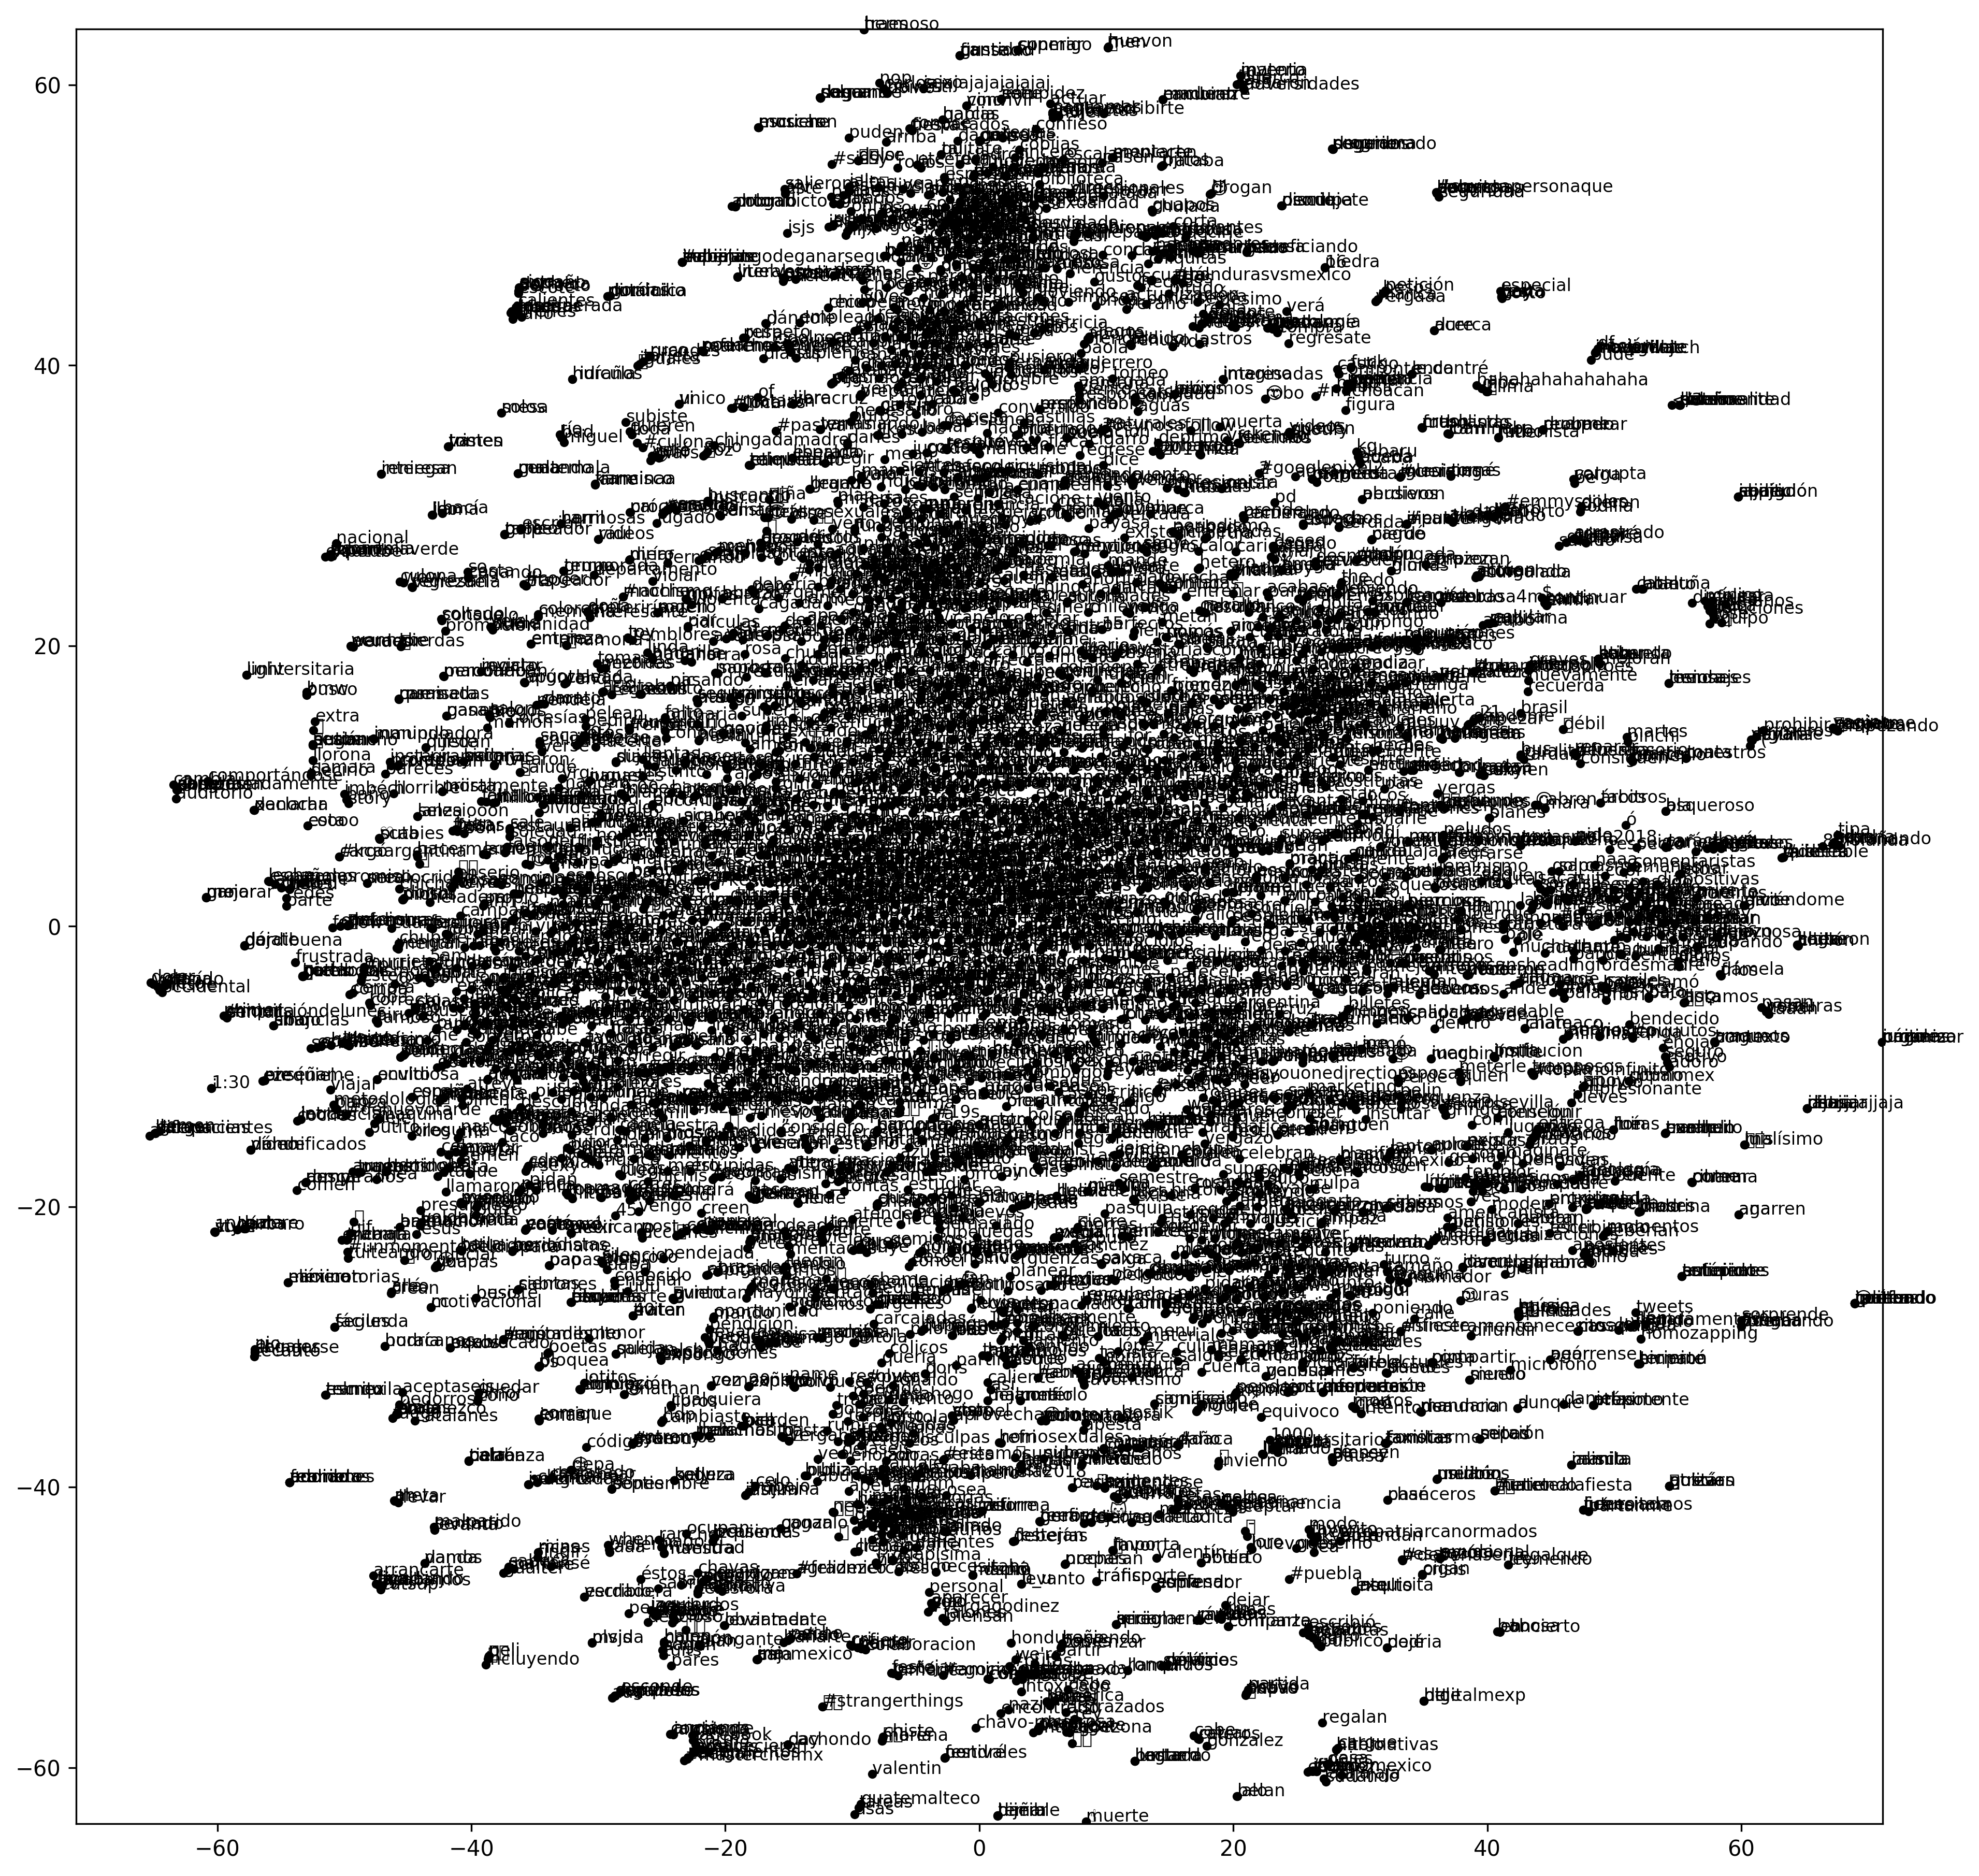

In [19]:
plots(reduced_RI, top_words, constellation = True)

**Subconjunto de constelación de palabras**

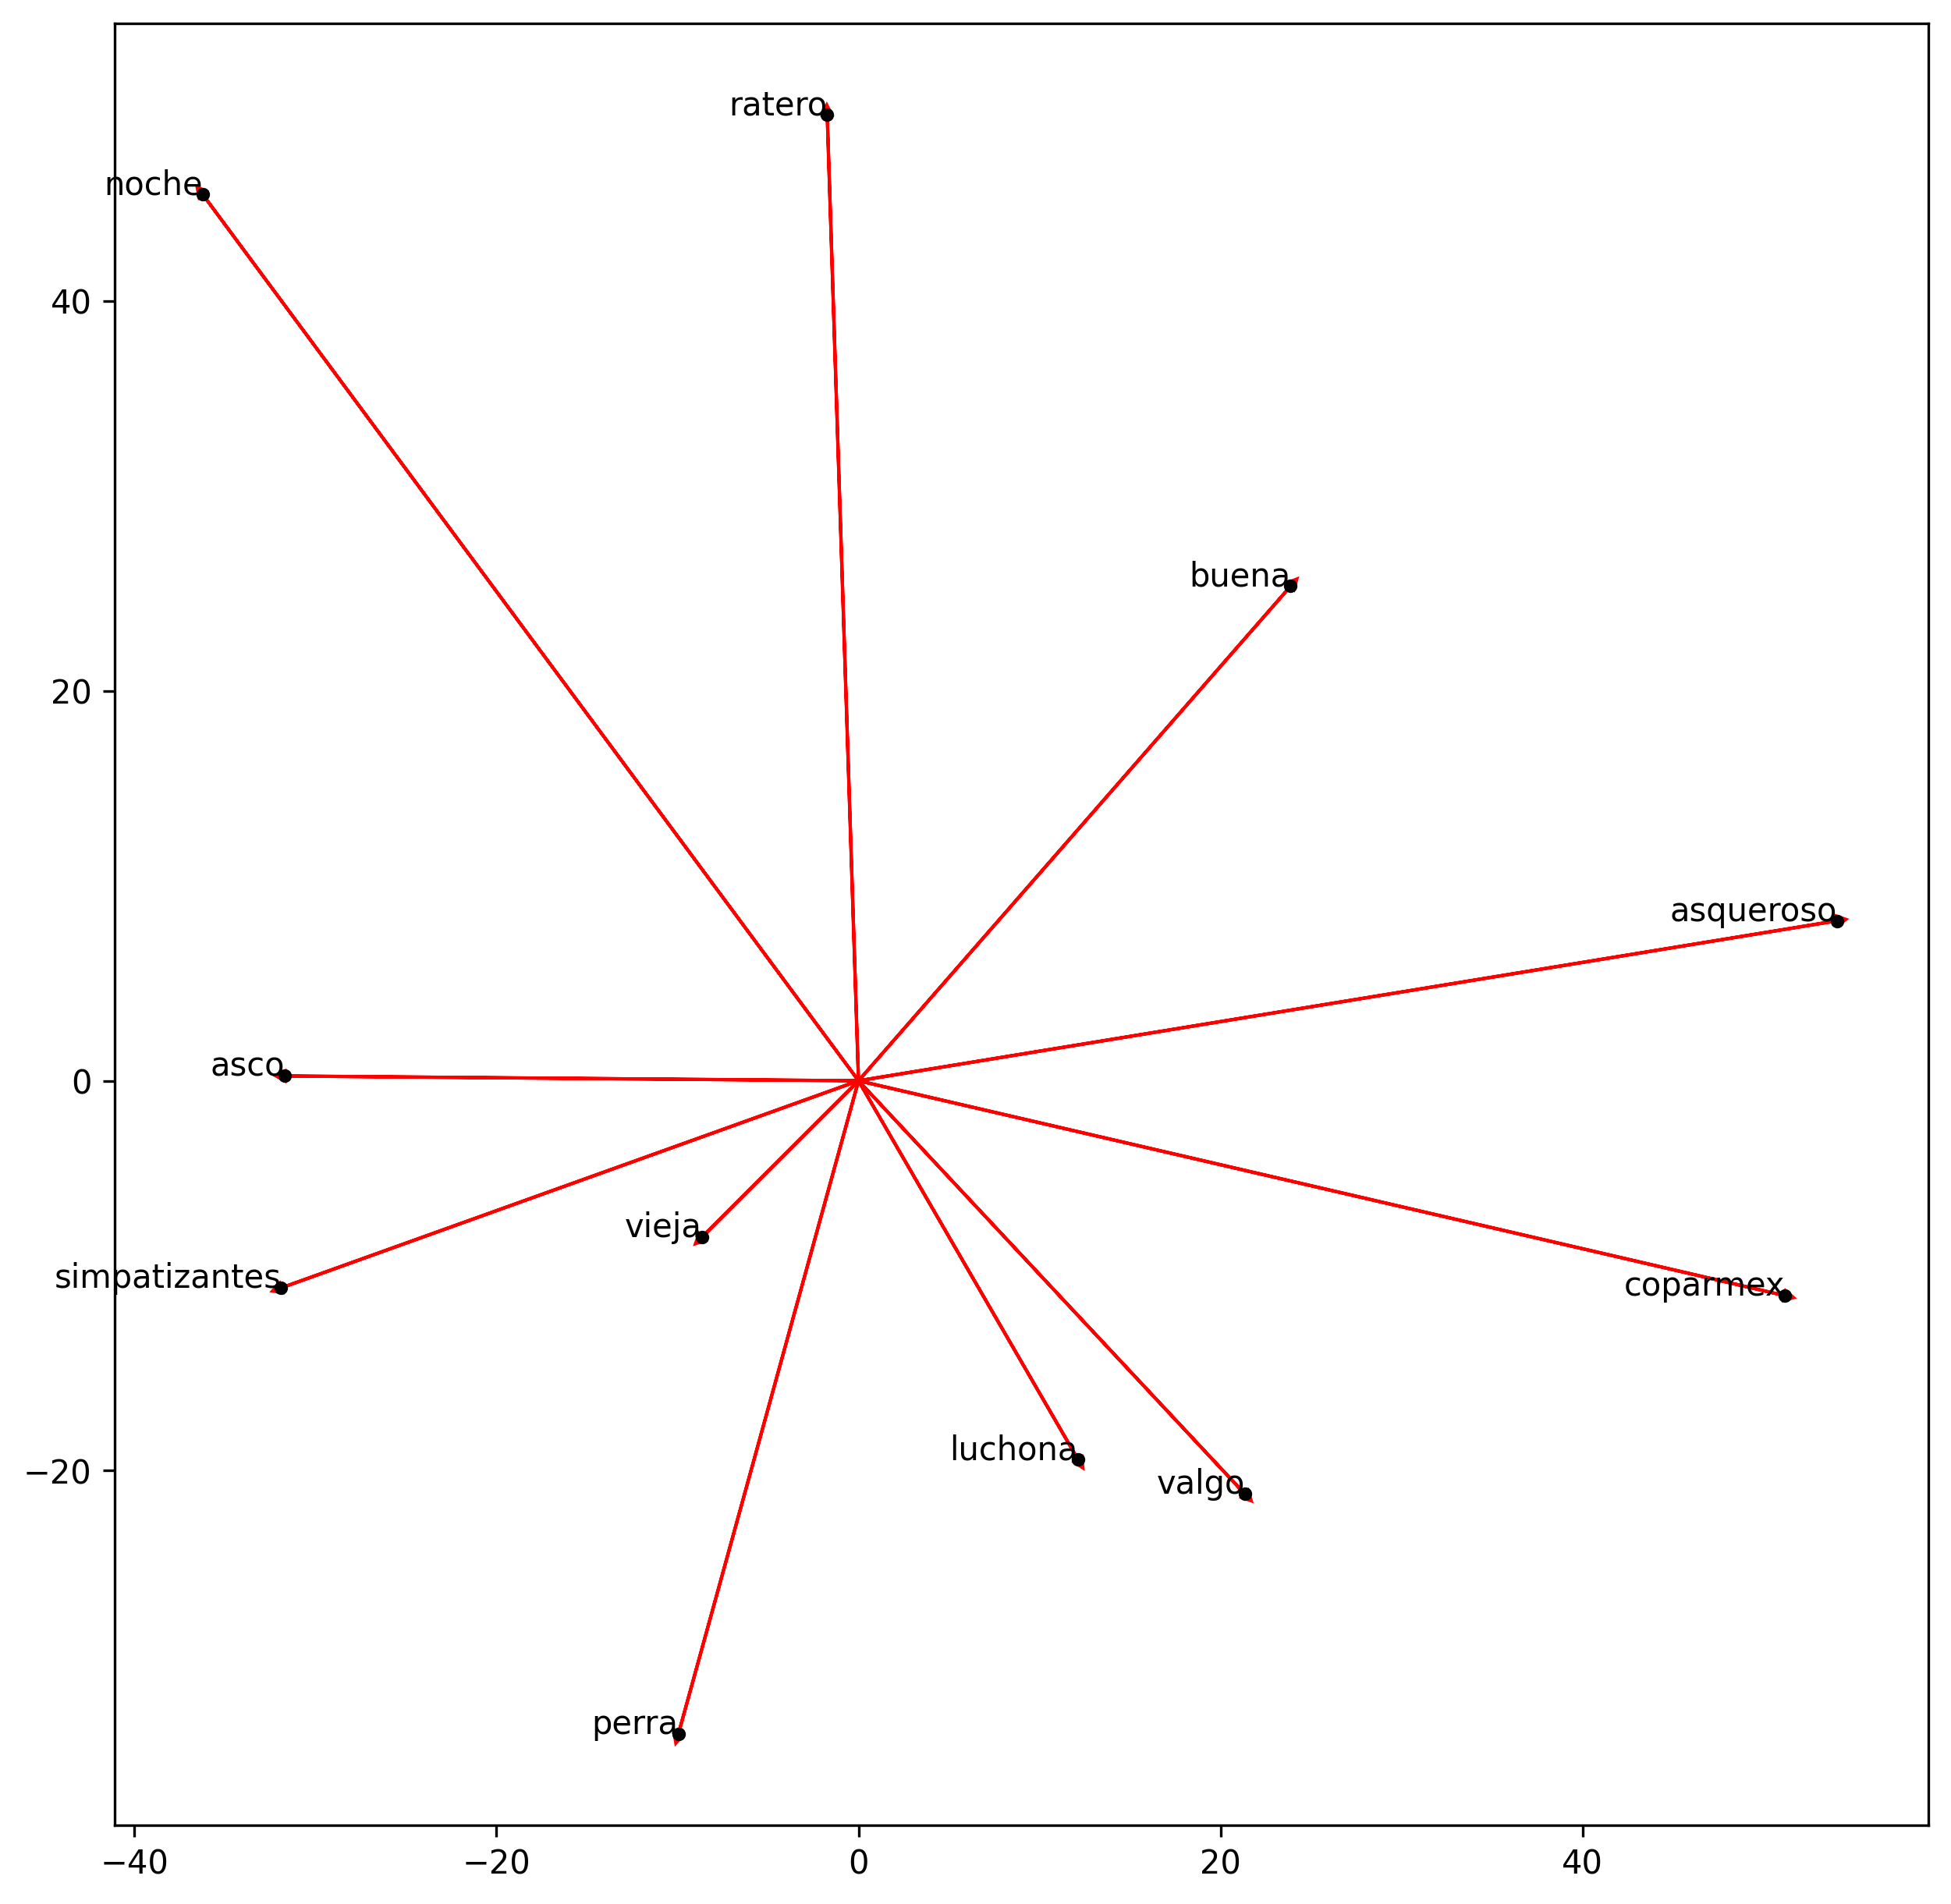

In [20]:
plots(reduced_RI, top_words, constellation = False)

> **COMENTARIO:**
>
> A comparación del ejercicio anterior, el tiempo de ejecución demoró mucho menos. Además, como el subconjunto para mostrar con las flechas es el mismo, podemos comparar más fácilmente. En este ejemplo podemos ver que:
>- "#NoEraPenal"
>- "#Holanda"
>
> Tienen el mismo comportamiento, además, es importante notar que 
>- "simpatizantes"
>- "coparmex"
>
> Son casi colineales (resultan ser los que tienen similitud del coseno más alta y se ve en un ejercicio posterior).


### **1.2.3.- Use alguna de las DTRs anteriores por separado de alguna forma para clasificación de documentos (e.g., promedio de vectores de términos en cada documento para representar). Compárelas contra un BoW-TFIDF de 5000 palabras más frecuentes.**

> Se usará la función *SVM_classification()*, definida inicialmente en la **tarea 2**, en la cual resume una clasificación SVM como en la **práctica 3**. Se le hicieron algunos cambios para adaptarla a nuestros nuevos problemas, ahora toma como argumento principal a las matrices de **representación** de los datos de entrenamiento y de validación, así como parámetros auxiliares del clasificador (se usaron los mismos para mejor comparación). La función regresa el reporte de clasificación, el número de predicciones incorrectas y la matriz de confusión.

In [21]:
# Hiperparámetros y configuración
param_grid = {'C': [0.05, .12, .25, .5, 1, 2, 4]}  # Parámetros a evaluar.
scoring = 'f1_macro'                               # Métrica a optimizar.
cv = 5                                             # Número de folds para validación cruzada.

def SVM_classification(X_train: np.ndarray, X_val: np.ndarray, labels_tr: list = labels_tr, labels_val: list = labels_val,
                       param_grid: dict = param_grid, scoring: str = scoring, cv: int = cv) -> None:
    """
    Train a linear SVM model and evaluate it on the validation data. The function performs the following steps:
        - Train a linear SVM model with 5-fold cross-validation.
        - Evaluate the model on the validation data.
        - Print the classification report.
        - Plot the confusion matrix.

    Parameters
    ----------
    X_train : np.ndarray
        Representation of the training data.
    X_val : np.ndarray
        Representation of the validation data.
    labels_tr : list, optional
        Training labels, by default labels_tr.
    labels_val : list, optional
        Validation labels, by default labels_val.
    param_grid : dict, optional
        Hyperparameter grid, by default param_grid = {'C': [0.05, .12, .25, .5, 1, 2, 4]}.
    scoring : str, optional
        Metric to optimize, by default scoring = 'f1_macro'.
    cv : int, optional
        Number of folds for cross-validation, by default cv = 5.
    """
    # Train a linear SVM.
    svc = svm.LinearSVC(class_weight = 'balanced', dual = False)  # Linear SVM. class_weight = 'balanced' assigns weights inversely proportional to class frequencies to compensate for class imbalance. dual = False is recommended when n_samples > n_features.
    grid = GridSearchCV(estimator = svc, param_grid = param_grid, # Grid search.
                        scoring = scoring, cv = cv, n_jobs = -1)  # 5-fold cross-validation. f1_macro is the F1 score for each class independently.
    
    # Train the model.
    grid.fit(X_train, labels_tr)

    # Predict the labels.
    label_pred = grid.predict(X_val)

    # Evaluate the model on the validation data.
    print("\nClassification Report:\n", metrics.classification_report(labels_val, label_pred))

    # Number of incorrect predictions.
    incorrect_indices = [i for i, (real, pred) in enumerate(zip(labels_val, label_pred)) if real != pred]
    print(f"\nNumber of incorrect predictions: {len(incorrect_indices)}\n")

    # Confusion matrix.
    cm = metrics.confusion_matrix(labels_val, label_pred)
    plt.figure(figsize = (7,5))
    sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Purples', xticklabels = set(labels_val), yticklabels = set(labels_val))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

> Comenzamos cargando la función *built_bow_tfidf()* definida en la **tarea 2**. Recordemos que para este problema de clasificación, fue la forma de pesado que nos dio mejores resultados con sólo $96$ errores y $84\%$ de accuracy, en su versión sin aplicar normalización L2.
>
>Creamos sus representaciones en las matrices **TFIDF_tr** y **TFIDF_val**:

In [22]:
def build_bow_tfidf(docs: list, vocab: list, word_index: dict, normalized: bool = True) -> np.ndarray:
    """
    Build a bag of words matrix. Rows are documents and columns are words. The weights are the TF-IDF values of the words
    in the documents. The matrix can be normalized by the L2 norm of the rows.
    
    Parameters
    ----------
    docs : list
        List of documents.
    vocab : list
        List of words.
    word_index : dict
        Dictionary with the indices of the words.
    normalized : bool
        If True, normalize the rows of the matrix by their L2 norm.

    Returns
    -------
    np.ndarray
        Bag of words matrix with TF-IDF weights.
    """
    N = len(docs)                                           # Number of documents.
    df = np.zeros(len(vocab), dtype = float)                # For calculate document frequency for each word.
    tfidf_matrix = np.zeros((N, len(vocab)), dtype = float) # For storing the TF-IDF values.

    # First, we count the number of documents that contain each word.
    for doc in docs:                         # Iterate over the documents.     
        words = set(tokenizer.tokenize(doc)) # Unique words in the document.
        for word in words:                   # Iterate over the words.
            if word in word_index:           # If the word is in the vocabulary.
                df[word_index[word]] += 1    # Increment the document frequency of the word.

    # Second, we calculate the IDF values.
    idf = np.log(N / (1 + df)) # log(N / (1 + df)) to avoid division by zero.

    # Finally, we calculate the TF-IDF values.
    for i, doc in enumerate(docs):                             # Iterate over the documents.
        word_counts = Counter(tokenizer.tokenize(doc))         # Count the words in the document.
        total_words = sum(word_counts.values())                # Total number of words in the document.
        for word, count in word_counts.items():                # Iterate over the words.
            if word in word_index:                             # If the word is in the vocabulary.
                tf = count / total_words                       # Calculate TF.
                word_idx = word_index[word]                    # Index of the word.
                tfidf_matrix[i, word_idx] = tf * idf[word_idx] # Calcular TF-IDF

    if normalized: # Normalize the rows of the matrix by their L2 norm.
        
        norms = np.linalg.norm(tfidf_matrix, axis = 1, keepdims = True) # Calculate the L2 norm of each row.
        norms[norms == 0] = 1                                           # Avoid division by zero.
        tfidf_matrix /= norms                                           # Normalize the rows.

    return tfidf_matrix

# Build the TF-IDF matrix.
TFIDF_tr = build_bow_tfidf(data_tr, top_words, dict_indices, normalized = False)  
TFIDF_val = build_bow_tfidf(data_val, top_words, dict_indices, normalized = False)
print("Shape of the TF-IDF matrix:", TFIDF_tr.shape)
print("Shape of the TF-IDF matrix:", TFIDF_val.shape)

Shape of the TF-IDF matrix: (5278, 5000)
Shape of the TF-IDF matrix: (587, 5000)


> Por simplicidad y menor tiempo de cómputo, decidí usar Random Indexing como DTR para la clasificación. Se probó como recomienda el ejercicio: promedio de vectores de términos en cada documento para representar, sin embargo, explorando con otras alternativas como la suma o el máximo de los vectores de términos en cada documento, se eligió tomar el máximo ya que es el que tuvo mejores resultados ($153$ errores y $74\%$ de accuracy).
>
>Creamos la función *doc_rep_from_RI()*. Esta genera una representación vectorial de documentos a partir de una DTR, (Random Indexing). Su objetivo es representar cada documento con un solo vector, calculando el promedio de los vectores de las palabras que lo componen en la matriz de Random Indexing. Podemos representar un documento tomando el promedio de los vectores de las palabras que lo componen:
    

In [23]:
def doc_rep_from_RI(docs: list, word_index: dict, RI_matrix: np.ndarray, normalized: bool = True,
                    method: str = "max") -> np.ndarray:
    """
    Represent each document as the average/max/sum of the Random Indexing vectors of the words in the document.

    Parameters
    ----------
    docs : list
        List of documents.
    word_index : dict
        Dictionary with the indices of the words.
    RI_matrix : np.ndarray
        Random Indexing matrix. Rows are words and columns are dimensions.
    normalized : bool, optional
        Normalize the matrix, by default True.
    method : str, optional
        Method to aggregate the word vectors. Options are "mean", "max", and "sum", by default "max".

    Returns
    -------
    np.ndarray
        Document representation matrix.
    """
    N = len(docs)                 # Number of documents.
    k = RI_matrix.shape[1]        # Dimensionality of RI vectors.
    doc_matrix = np.zeros((N, k)) # Matrix to store document vectors.

    for i, doc in enumerate(docs):                                                # Iterate over the documents.
        words = tokenizer.tokenize(doc)                                           # Tokenize the document.
        word_indices = [word_index[word] for word in words if word in word_index] # Get the indices of the words in the document (if they are in the vocabulary).
                                                                                  # Es decir, descartamos las palabras que no están en el vocabulario.
        
        if word_indices:                                                   # If there are words in the vocabulary.
            if method == "mean":                                           # If the method is the mean.
                doc_matrix[i] = np.mean(RI_matrix[word_indices], axis = 0) # Average the RI vectors of the words in the document.
            elif method == "max":                                          # If the method is the max.
                doc_matrix[i] = np.max(RI_matrix[word_indices], axis = 0)  # Max the RI vectors of the words in the document.
            elif method == "sum":                                          # If the method is the sum.
                doc_matrix[i] = np.sum(RI_matrix[word_indices], axis = 0)  # Sum the RI vectors of the words in the document.
    
    if normalized: # Normalize the rows of the matrix by their L2 norm.
        
        norms = np.linalg.norm(doc_matrix, axis = 1, keepdims = True) # Calculate the L2 norm of each row.
        norms[norms == 0] = 1                                         # Avoid division by zero.
        doc_matrix /= norms                                           # Normalize the rows.

    return doc_matrix 

# Build the document representation matrix from Random Indexing.
RI_doc_tr = doc_rep_from_RI(data_tr, dict_indices, RI_matrix, method = "max")
RI_doc_val = doc_rep_from_RI(data_val, dict_indices, RI_matrix, method = "max")
print("Shape of the DTR matrix:", RI_doc_tr.shape)
print("Shape of the DTR matrix:", RI_doc_val.shape)

Shape of the DTR matrix: (5278, 300)
Shape of the DTR matrix: (587, 300)


----------------------------------------------------------------------
SVM with TF-IDF weights:
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.87      0.88       418
           1       0.69      0.71      0.70       169

    accuracy                           0.82       587
   macro avg       0.79      0.79      0.79       587
weighted avg       0.83      0.82      0.83       587


Number of incorrect predictions: 103



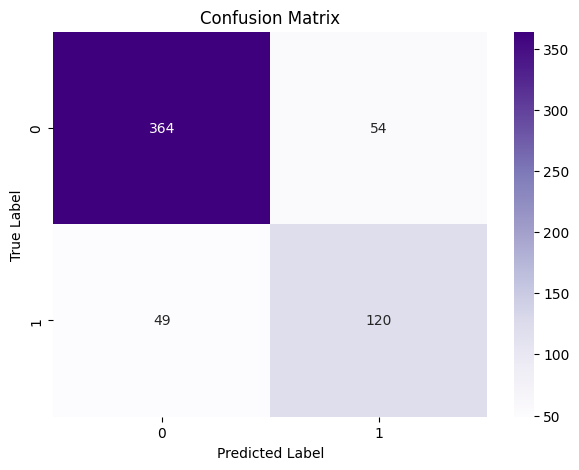

In [24]:
# Train a linear SVM with TF-IDF weights.
print(70*"-")
print("SVM with TF-IDF weights:")
print(70*"-")
SVM_classification(TFIDF_tr, TFIDF_val)

----------------------------------------------------------------------
SVM with Random Indexing representation:
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.76      0.79       418
           1       0.49      0.59      0.54       169

    accuracy                           0.71       587
   macro avg       0.66      0.67      0.66       587
weighted avg       0.73      0.71      0.72       587


Number of incorrect predictions: 171



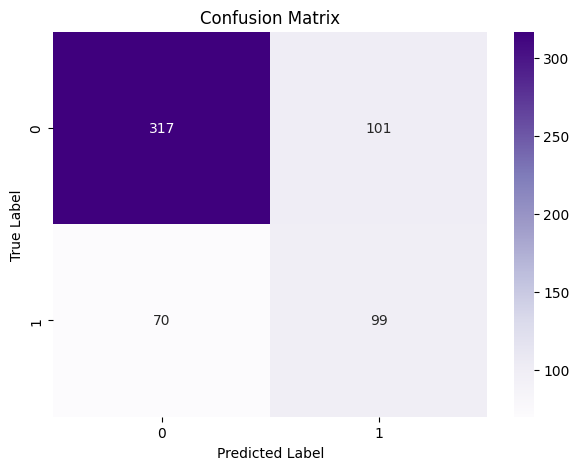

In [26]:
# Train a linear SVM with Random Indexing representation.
print(70*"-")
print("SVM with Random Indexing representation:")
print(70*"-")
SVM_classification(RI_doc_tr, RI_doc_val)

> **COMENTARIO:**
>
>Al comparar los dos enfoques: TF-IDF vs. Random Idexing para clasificación de documentos (usando el máximo de los vectores de términos en cada documento para representar) volvió a suceder lo mismo que en la tarea pasada, es decir, TF-IDF tuvo mucho mejor resultado que su rival. Elegí usar el máximo de los vectores para representar ya que tuvo mejores resultados que mis otras dos propuestas (promedio y suma). Además, esto tiene sentido ya que el usar el máximo, estamos resaltando las características dominantes.
>
>| Model                           | Accuracy | Macro Avg Precision | Macro Avg Recall | Macro Avg F1-Score | Incorrect Predictions |
>|---------------------------------|----------|----------------------|------------------|---------------------|-----------------------|
>| SVM with TF-IDF weights        | 0.84     | 0.80                 | 0.81             | 0.81                | 96                    |
>| SVM with Random Indexing       | 0.74     | 0.69                 | 0.72             | 0.70                | 153                   |
>

### **1.2.4.- Bajo la representación TCOR de los términos, y asumiendo un vocabulario de 5000 palabras, muestre por orden de mayor similitud coseno (ver chp 6 del libro de Dan) los 10 pares de palabras más parecidas en toda la colección.**

>Del capítulo 6 del libro de Dan Jurafsky, tenemos que para medir la similitud entre dos palabras $w_i$ y $w_j$, se usa el coseno del ángulo entre los vectores representantes de estas palabras ($\bar{w}_i$ y $\bar{w}_j$), i.e.,
>$$
> cosine(\bar{w}_i, \bar{w}_j) = \frac{\bar{w}_i \cdot \bar{w}_j}{|\bar{w}_i| \cdot |\bar{w}_j|}
>$$
> donde $|\cdot|$ es la norma L2.
>
> Recordemos que la representación TCOR de los primeros $5000$ términos más comúnes la tenemos almacenada en la variable **TCOR_BASE**. Cada elemento en la fila $i$ indica la correlación de la palabra $w_i$ con otra palabra $w_j$, dado esto, podemos calcular el producto $\bar{w}_i \cdot \bar{w}_j$ calculando $T_{COR}\cdot T_{COR}^T$ ya que esto es el producto punto para cada par de vectores de representación de las palabras. Como se mencionó antes, es importante eliminar la auto-ococurrencia, es decir, hacer la diagonal de la matriz igual a cero, así evitamos que cada palabra sea su par más similar.
>
>Además, dado que la matriz TCOR ya está normalizada por filas, entonces, podemos omitir el denominador ya que $|\bar{w}_i|=1$, para todas las palabras en el vocabulario.
>
> Con esto, es necesario encontrar los pares de vectores de representación que tengan mayor similitud del coseno, extraer sus índices en el diccionario y su correspondiente palabra, esto se hace en la función *most_similar_terms()*:


In [27]:
def most_similar_terms(TCOR_BASE: np.ndarray, dict_index_inv: dict, top_k: int = 10) -> pd.DataFrame:
    """
    Compute the most similar terms based on the TCOR matrix. The function performs the following steps:
        1. Compute the similarity matrix.
        2. Remove self-similarity (diagonal elements).
        3. Extract all unique term pairs.
        4. Extract similarity values for each pair.
        5. Sort by highest similarity.
    
    Parameters
    ----------
    TCOR_BASE : np.ndarray
        TCOR matrix.
    dict_index_inv : dict
        Dictionary with the indices of the words.
    top_k : int, optional
        Number of most similar terms to extract, by default 10.
    
    Returns
    -------
    list
        List of tuples with the most similar terms, their indices, and the cosine similarity.
    """
    n_terms = TCOR_BASE.shape[0]                  # Number of terms.
    similarity_matrix = TCOR_BASE @ TCOR_BASE.T   # Compute the similarity matrix.
    np.fill_diagonal(similarity_matrix, 0)        # Remove self-similarity.

    pairs = list(combinations(range(n_terms), 2)) # All the possible pairs of terms (without repetition).
                                                  # Example: [(0, 1), (0, 2), ..., (0, n-1), (1, 2), ..., (n-2, n-1)]

    # Extract the similarity values for each pair of terms.
    similarities = [(i, dict_index_inv[i], j, dict_index_inv[j], similarity_matrix[i,j]) for i, j in pairs]

    # Sort by highest similarity and get the top k pairs.
    top_similar_pairs = sorted(similarities, key = lambda x: x[-1], reverse = True)[:top_k]

    # Create a DataFrame with the top k pairs.
    top_similar_pairs = pd.DataFrame(top_similar_pairs, columns =
                                     ["Index 1", "Word", "Index 2", "Word", "Cosine Similarity"],
                                     index = range(1, top_k+1))
    return top_similar_pairs

# Obtain the 10 most similar terms.
top_10_pairs = most_similar_terms(TCOR_BASE, dict_index_inv, top_k = 10)
print("10 pares de palabras más parecidas en toda la colección son:")
top_10_pairs

10 pares de palabras más parecidas en toda la colección son:


,Index 1,Word,Index 2,Word,Cosine Similarity
1,65,“,70,”,0.942808
2,55,(,57,),0.917618
3,2657,✅,2658,🚫,0.892753
4,4931,warner,4932,calentó,0.882522
5,4931,warner,4933,motores,0.882522
6,4931,warner,4934,estudios,0.882522
7,4931,warner,4935,comiencen,0.882522
8,4931,warner,4936,porcentaje,0.882522
9,4931,warner,4937,cuota,0.882522
10,4931,warner,4938,dinsey,0.882522


> **COMENTARIO:**
>
> Hace mucho sentido que los dos primeros pares de términos más relacionados bajo la métrica del coseno sean <“,”> y <(,)> ya que son caracteres que siempre se encuentran entre sí. Podríamos quitar esto eliminando los stopwords. Además, notamos que las palabras que tiene mayor similitud con otras son "coparmex" y "simpatizantes" por lo que se espera que el par <coparmex, simpatizantes> sea el de mayor similitud coseno, y así fue. En el gráfico de flechas se notó si relación siendo casi colineales.

### **1.2.5.- Bajo alguna representación de documentos hecha en esta tarea, y asumiendo un vocabulario de 5000 palabras, muestre por orden de más similitud coseno (ver chp 6 del libro de Dan) 10 pares de documentos más parecidos en toda la colección (no muestres pares de documentos que contengan exactamente substrings uno del otro; pues hay algo de redundancia en los datos). Muestre el texto que contienen y muestre la categoría de cada uno.**

>Del capítulo 6 del libro de Dan Jurafsky, tenemos que para medir la similitud entre dos documentos $d_i$ y $d_j$, se usa el coseno del ángulo entre los vectores representantes de estos documentos ($\bar{d}_i$ y $\bar{d}_j$), i.e.,
>$$
> cosine(\bar{d}_i, \bar{d}_j) = \frac{\bar{d}_i \cdot \bar{d}_j}{|\bar{d}_i| \cdot |\bar{d}_j|}
>$$
> donde $|\cdot|$ es la norma L2.
>
> Podemos calcular el producto $\bar{d}_i \cdot \bar{d}_j$ calculando $T_{doc}\cdot T_{doc}^T$ donde $T_{doc}$ es una matriz de representación de documentos ya que esto es el producto punto para cada par de vectores de representación de los documentos. Como se mencionó antes, es importante eliminar la auto-ococurrencia, es decir, hacer la diagonal de la matriz igual a cero, así evitamos que cada documento sea su par más similar.
>
> Afortunadamente, del **ejercicio 1.2.3** se tiene la función *doc_rep_from_RI()* la cual regresa una representación de documentos heredada de una representación TCOR que suma, promedia o saca el máximo de los vectores que representan los términos de cada documento (bajo el vocabulario de $5000$ palabras), así que será usado en este ejercicio (solo imprimí el que calcula el máximo). Además, recordemos que la representación TF-IDF también podría ser usada. Sin embargo, por simplicidad, en la función de a continuación, se asume que la matriz de representación de documentos ya se encuentra normalizada por filas y así omitir el denominador ya que $|\bar{d}_i|=1$, para todos los documentos.


In [28]:
# Build the document representation matrix from Random Indexing.
RI_doc_max = doc_rep_from_RI(data_tr, dict_indices, RI_matrix, method = "max")

> **NOTA:** Debido a la similitud gigante entre muchos de los tweets (algunos únicamente diferentes por un espacio, un caracter o algún símbolo), se intentaron varios pasos de preprocesamiento, pero preferí quedarme con:
>- Extraer todos los N-gramas (ejemplo: 7-gramas) de cada tweet y si dos tweets comparten al menos un N-grama exacto, se descartan de la lista de pares más similares. Elegí 7 porque N-gramas de $1,2,\dots,6$ palabras pueden ser bastante comúnes, según vi en los datos, ya que no se eliminaron los stopwords.
>
>Incluso con 5 funciona bien. Esto se hace con ayuda de la función *extract_ngrams()*:

In [30]:
def extract_ngrams(docs, n = 4):
    """
    Extract N-grams from a list of documents.
    """
    return set(tuple(docs[i:i+n]) for i in range(len(docs) - n + 1))

print("Ejemplo de uso:")
extract_ngrams(tokenizer.tokenize('Extract N-grams from a list of documents.'))

Ejemplo de uso:


{('a', 'list', 'of', 'documents'),
 ('extract', 'n-grams', 'from', 'a'),
 ('from', 'a', 'list', 'of'),
 ('list', 'of', 'documents', '.'),
 ('n-grams', 'from', 'a', 'list')}

Con esto, es necesario encontrar los pares de vectores de representación que tengan mayor similitud del coseno, extraer sus índices y su correspondiente contenido, esto se hace en la función *most_similar_documents()*:

In [33]:
def most_similar_documents(doc_matrix: np.ndarray, docs: list = data_tr, labels: list = labels_tr,
                           top_k: int = 10, ngram_size: int = 7) -> pd.DataFrame:
    """
    Find the top-k most similar pairs of documents based on cosine similarity,
    avoiding nearly identical tweets by detecting shared N-grams.

    Parameters
    ----------
    doc_matrix : np.ndarray
        Document representation matrix (e.g., BoW-TFIDF, RI, etc.).
    docs : list, optional
        List of original document texts. Default is the training data.
    labels : list, optional
        List of document labels. Default is the training labels.
    top_k : int, optional
        Number of most similar pairs to return, default is 10.
    ngram_size : int, optional
        N-gram size for filtering, default is 7.

    Returns
    -------
    pd.DataFrame
        DataFrame with most similar document pairs, their texts, labels, and similarity scores.
    """
    n_docs = doc_matrix.shape[0]                  # Number of documents.
    similarity_matrix = doc_matrix @ doc_matrix.T # Compute the similarity matrix.
    np.fill_diagonal(similarity_matrix, 0)        # Remove self-similarity.

    pairs = list(combinations(range(n_docs), 2)) # All the possible pairs of docs (without repetition).
                                                 # Example: [(0, 1), (0, 2), ..., (0, n-1), (1, 2), ..., (n-2, n-1)]

    similarities = [(i, j, similarity_matrix[i,j]) for i, j in pairs]               # Extract similarity values for each pair of docs.
    top_similar_pairs = sorted(similarities, key = lambda x: x[-1], reverse = True) # Sort by highest similarity.
    doc_ngrams = [extract_ngrams(doc, n = ngram_size) for doc in docs]              # Extract N-grams from the documents.

    # Filter out substring redundancy
    filtered_pairs = []
    for i, j, sim in top_similar_pairs:                   # Iterate over the top similar pairs.
        if not doc_ngrams[i].intersection(doc_ngrams[j]): # If there are no shared N-grams.
            filtered_pairs.append((i, j, sim))            # Add the pair to the filtered pairs.
        if len(filtered_pairs) >= top_k:                  # If we have the top k pairs.
            break                                         # Break.

    # Create a DataFrame with the top k pairs.
    df_top_similar = [(i, docs[i], labels[i], j, docs[j], labels[j], sim) for i, j, sim in filtered_pairs]
    df_top_similar = pd.DataFrame(df_top_similar,
                                  columns = ["Index 1", "Text 1", "Label", "Index 2", "Text 2", "Label", "Cosine Similarity"],
                                  index = range(1, top_k + 1))

    return df_top_similar

# Find the 10 most similar documents.
top_10_docs = most_similar_documents(RI_doc_max, data_tr, labels_tr, top_k = 10, ngram_size = 4)
print("10 pares de documentos más parecidos en toda la colección son:")
top_10_docs

10 pares de documentos más parecidos en toda la colección son:


,Index 1,Text 1,Label,Index 2,Text 2,Label,Cosine Similarity
1,1899,PUES QUE PUTO YA LLEGALE A LA VERGA PINCHE CAC...,1,4168,Menos tu por pinche gorda\n,1,0.976840
2,1458,Gorda! Muy gorda que se me hace!\n,0,2342,#ConSalvadorIglesias habrá putas para todos!!!...,0,0.971193
3,1793,A mi se me hace gorda pero la vergota!\n,0,2342,#ConSalvadorIglesias habrá putas para todos!!!...,0,0.971193
4,2759,"Si te apasiona, rómpete la madre.#berraco\n",0,4799,"TOUCHDOWN DALLAS. Te amo, @USUARIO Eres el put...",0,0.968364
5,210,"No sé ustedes, pero a mí se me hace gorda.\n",0,2759,"Si te apasiona, rómpete la madre.#berraco\n",0,0.966793
6,935,"A un hombre le gusta una mujer fiestera, loca ...",0,2759,"Si te apasiona, rómpete la madre.#berraco\n",0,0.965417
7,442,"@USUARIO No mames, ese episodio es una cosa mu...",0,3014,"No tengo ni madre, lo sé. 😂😂😂😂\n",0,0.965194
8,3014,"No tengo ni madre, lo sé. 😂😂😂😂\n",0,4799,"TOUCHDOWN DALLAS. Te amo, @USUARIO Eres el put...",0,0.964915
9,1657,"Ahí van a mamar con los gobernantes jajaja, ya...",1,3711,"No, señora, tomarle fotos encuerado a un joto ...",0,0.964553
10,397,¿cómo identificar a un machito que siente que ...,0,3999,Chingo mi madre. ¿Si era muy necesario enferma...,0,0.964484


> **COMENTARIO:**
>
>Después de varios intentos de encontrar los 10 tweets con similaridad del coseno más alta sin que hubiera intersección de substrings, se obtuvieron estos resultados con mucha menor redundancia gracias a ignorar tweets similares por 7-gramas. Si revisamos estos tweets completos vemos que si son bastante similares en el mensaje que quieren dar y por las palabras en común que usan, sin tanta redundancia., por ejemplo:

In [35]:
print("Tweets con mayor similaridad:\n\n", data_tr[1899], data_tr[4168])

Tweets con mayor similaridad:

 PUES QUE PUTO YA LLEGALE A LA VERGA PINCHE CACHAGRANIZO
 Menos tu por pinche gorda



### **1.2.6.- Implemente Ganancia de Información o Chi2 como lo sugiere Baeza-Yates (no función de sklearn ni similar) para descubrir el top 50 de las palabras más relevantes de TODA la colección. Haga una gráfica también con la herramienta de word_cloud dónde el tamaño de la palabra corresponda a su ganancia de información o Chi2:**
- **https://amueller.github.io/word_cloud/**

> Recordemos los aspectos principales de la Ganancia de Información según el paper:
>
>La Ganancia de Información mide la reducción en la incertidumbre al conocer la presencia de una palabra $k_i$ en la colección $\mathcal{C}$. La fórmula en el artículo es:
>$$
>I G\left(k_i, \mathcal{C}\right)=-\sum_{p=1}^L\left(\frac{n_p}{N_t} \log \left(\frac{n_p}{N_t}\right)-\frac{n_{i, p}}{N_t} \log \left(\frac{n_{i, p}}{n_i}\right)-\frac{n_p-n_{i, p}}{N_t} \log \left(\frac{n_p-n_{i, p}}{N_t-n_i}\right)\right)
>$$
> Donde:
>- $N_t$ es el número total de documentos en la colección.
>- $L$ es el número total de clases (en un problema de clasificación).
>- $n_p$ es la cantidad total de documentos en la colección que pertenecen a la clase $p$.
>- $n_{i,p}$ es la cantidad de documentos de la clase $p$ que contienen la palabra $k_i$.
>- $n_i$ es la cantidad total de documentos que contienen la palabra $k_i$.


1. Entropía total: Representa la incertidumbre inicial en la clasificación de documentos.
$$
ENTROPY(C, n_p, N_t) = -\sum_{p=1}^L \frac{n_p}{N_t} \log \left(\frac{n_p}{N_t}\right)
$$

In [36]:
def entropy(class_counts: Counter, total: int) -> float:
    """
    Calculate the entropy of a set of classes.

    Parameters
    ----------
    class_counts : Counter
        Counter with the class counts.
    total : int
        Total number of samples.

    Returns
    -------
    float
        Entropy value.
    """
   
    return -sum((n_p / total) * np.log2(n_p / total) for n_p in class_counts.values() if n_p > 0)

2. Entropía condicional (cuando aparece $k_i$): Mide la incertidumbre en la clasificación cuando la palabra $k_i$ está presente.
$$
H(C | k_i) = -\sum_{p=1}^L \frac{n_{i, p}}{N_t} \log \left(\frac{n_{i, p}}{n_i}\right)
$$

3. Entropía condicional (cuando no aparece $k_i$): Mide la incertidumbre en la clasificación cuando la palabra $k_i$ no está presente.
$$
H(C | \neg k_i) = -\sum_{p=1}^L \frac{n_p - n_{i, p}}{N_t} \log \left(\frac{n_p - n_{i, p}}{N_t - n_i}\right)
$$

4. Ganancia de Información: Es la diferencia entre la entropía inicial y la entropía condicional al conocer la palabra:
$$
IG(k_i, \mathcal{C}) = H(C) - H(C | k_i) - H(C | \neg k_i)
$$
$$
=-\sum_{p=1}^L\left(\frac{n_p}{N_t} \log \left(\frac{n_p}{N_t}\right)-\frac{n_{i, p}}{N_t} \log \left(\frac{n_{i, p}}{n_i}\right)-\frac{n_p-n_{i, p}}{N_t} \log \left(\frac{n_p-n_{i, p}}{N_t-n_i}\right)\right)
$$
$$
= ENTROPY(C, n_p, N_t) - \frac{n_i}{N_t} ENTROPY(C, n_{i,p}, n_i) - \frac{N_t-n_i}{N_t}ENTROPY(C,n_p-n_{i,p},N_t-n_i)
$$

In [37]:
def information_gain(k_i: str, corpus: list, labels_tr: list) -> float:
    """
    Calculate the information gain of a term in the dataset.

    Parameters
    ----------
    k_i : str
        Term to calculate the information gain.
    corpus : list
        List of documents.
    labels_tr : list
        List of labels.

    Returns
    -------
    float
        Information gain value.
    """
    N_t = len(corpus)                                              # Number of documents.
    n_p = Counter(labels_tr)                                       # Number of documents in each class.
    indices_with_k_i = [i for i in range(N_t) if k_i in corpus[i]] # Indices of documents that contain k_i.
    n_i = len(indices_with_k_i)                                    # Number of documents that contain k_i.
    n_p_i = Counter(labels_tr[i] for i in indices_with_k_i)        # Number of documents in each class that contain k_i.         
    n_p_not_i = {p: n_p[p] - n_p_i.get(p, 0) for p in n_p}         # Number of documents in each class that do not contain k_i.
    
    H_C = entropy(n_p, N_t)                                                     # Calculate H(C)
    H_C_given_k_i = entropy(n_p_i, n_i) if n_i > 0 else 0                       # Calculate H(C | k_i) 
    H_C_given_not_k_i = entropy(n_p_not_i, N_t - n_i) if (N_t - n_i) > 0 else 0 # Calculate H(C | not k_i)

    # Calculate the information gain.
    IG = H_C - (n_i / N_t) * H_C_given_k_i - ((N_t - n_i) / N_t) * H_C_given_not_k_i
    return IG

Para las 10,000 palabras más frecuentes

In [38]:
top_words_10000 = [word for word, _ in fdist.most_common(10000)]                           # Select the 10,000 most frequent words.
word_ig = {k_i: information_gain(k_i, tr_corpus_tk, labels_tr) for k_i in top_words_10000} # Calculate the information gain of each term.
top_words_ig = sorted(word_ig.items(), key = lambda x: x[1], reverse = True)[:50]          # Sort the terms by information gain.

print("Top 50 palabras por Ganancia de Información:\n")
print(pd.DataFrame(top_words_ig, columns = ["Word", "Information Gain"], index = range(1, 51)))

Top 50 palabras por Ganancia de Información:

          Word  Information Gain
1          hdp          0.036950
2       pinche          0.024959
3        putos          0.022384
4         loca          0.020248
5           tu          0.018806
6           me          0.017925
7      pendejo          0.015281
8      maricon          0.014840
9         hijo          0.013923
10        puta          0.012932
11      mierda          0.010885
12       estoy          0.009666
13     pinches          0.009334
14          mi          0.009214
15       hijos          0.008059
16    pendejos          0.007365
17       perra          0.007270
18         soy          0.007234
19       golfa          0.006820
20  hondureños          0.005806
21      chinga          0.005719
22        joto          0.005624
23      putita          0.005314
24          yo          0.005287
25   lameculos          0.005186
26     luchona          0.005081
27    chinguen          0.004981
28       cosas          0.0049

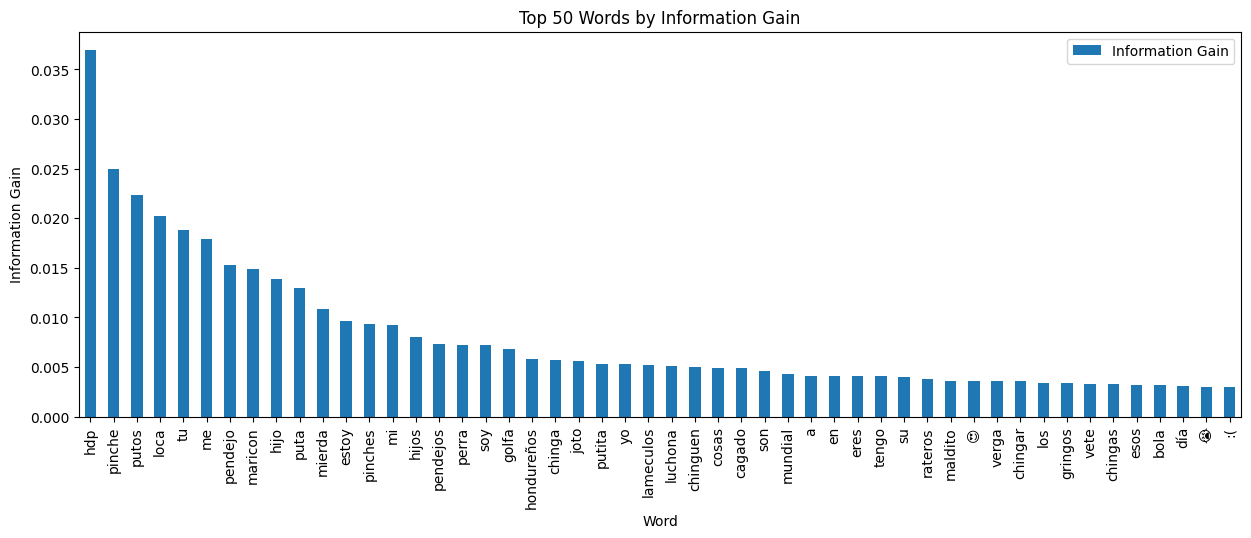

In [39]:
pd.DataFrame(top_words_ig, columns = ["Word", "Information Gain"]).plot(x = "Word", y = "Information Gain", kind = "bar", figsize = (15,5))
plt.ylabel("Information Gain")
plt.title("Top 50 Words by Information Gain")
plt.show()

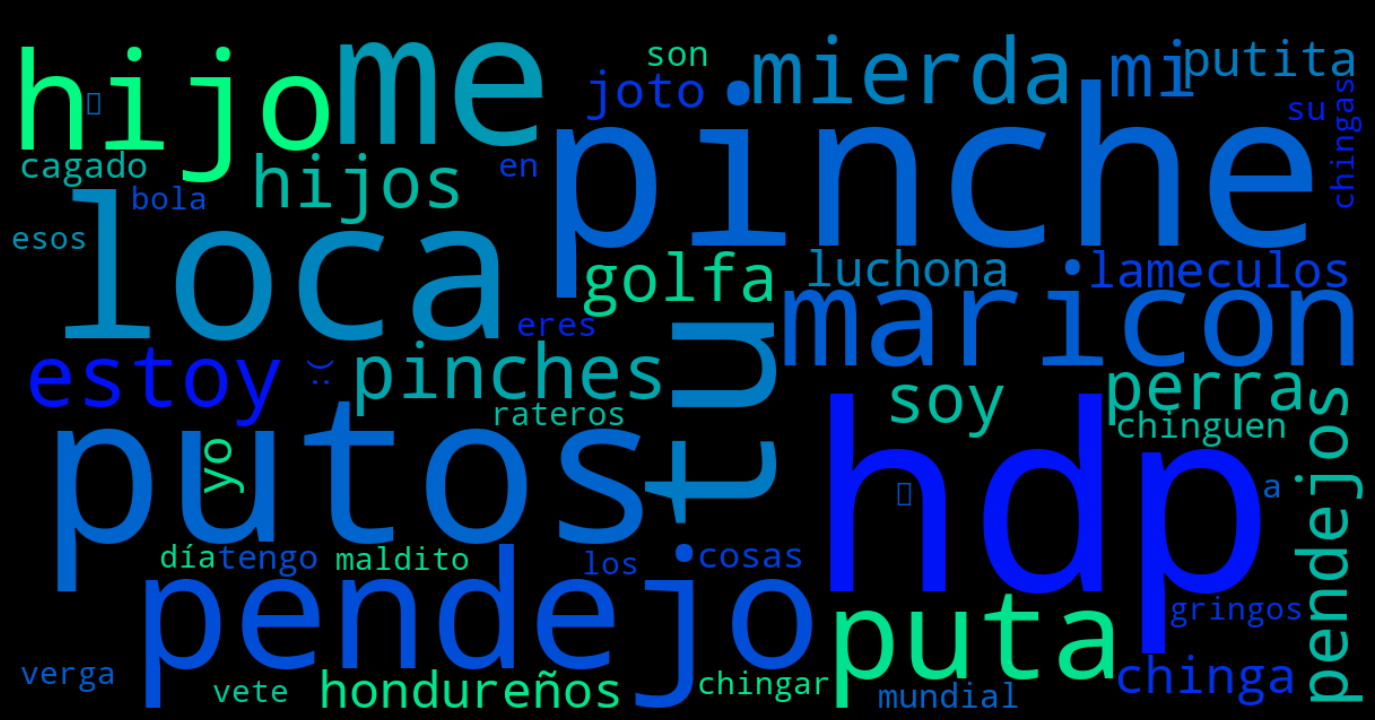

In [40]:
# Create a word cloud with the top 50 words by information gain.
wordcloud = WordCloud(
    width = 1200, height = 600, background_color = 'black', colormap = 'winter',
    contour_color = None, contour_width = 0, max_words = 50).generate_from_frequencies(word_ig)

# Plot the word cloud.
plt.figure(figsize = (14,7), facecolor = 'black')
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis("off")
plt.title("Top 50 Words by Information Gain")
plt.tight_layout(pad = 0)
plt.show()